# Indoor localization with WiFi signals using kNN regression

## Problem statement

Indoor localization remains a challenging task, as conventional GPS systems are unreliable or unavailable in enclosed environments. One promising alternative is WiFi-based fingerprinting, where received signal strength values (RSSI) collected at various reference locations are used as unique “fingerprints” to infer the current position. These fingerprints serve as input to machine learning models capable of predicting the user's coordinates indoors.

In this project, we approach the localization problem as a regression task using a non-standard application of the k-Nearest Neighbors (kNN) algorithm. Due to its non-parametric nature, kNN is particularly suitable for noisy, high-variance input data like RSSI values. The predicted location is derived by averaging the coordinates of the k most similar reference fingerprints.

An additional complexity lies in the influence of user orientation, which can significantly distort RSSI readings due to body shadowing effects. Therefore, orientation will be incorporated indirectly by filtering training data to include only samples with similar angles. The ultimate goal is to build a carefully reasoned, transparent data pipeline that takes us from raw signal measurements to accurate indoor position estimation, demonstrating the potential of machine learning (particularly kNN) in this unconventional context.

## Data collection

To build and evaluate the localization model, we use a pre-collected dataset with an offline (calibration) phase and an online (test) phase. The indoor test environment is a single-floor area where reference points were laid out on a 1 meter grid (166 points in total). The building is equipped with nine WiFi access points (APs): five Linksys/Cisco WRT54GS and four Lancom L-54g devices, all operating on IEEE 802.11b/g. Among these APs, one Lancom and all five Linksys units are located on the same floor as the test area, while the other three Lancom APs are elsewhere in the building (on different floors). This setup ensures that at any location in the test area, multiple AP signals can be received, albeit with varying strength depending on distance and obstacles.

### Offline phase (Calibration)
During the offline phase, a radio map of the environment was collected: at each of the 166 reference points, signal strength readings from all detectable WiFi APs were recorded for multiple orientations. In total, 110 samples were taken for each reference point and orientation, resulting in 146,080 measurements for the offline phase. The user orientation was recorded using a digital compass in degrees; typically, readings were taken in eight evenly spaced directions (e.g., 0°, 45°, 90°, ... 315°) to account for orientation-dependent signal attenuation. Each sample (each line in the trace file) includes the following information:
* **Timestamp** - the time of the measurement (in milliseconds since Jan 1, 1970 UTC).
* **Device ID (id)** - the MAC address of the scanning device (the mobile device collecting the data).
* **Position (pos)** - the actual physical coordinates of the device in the format (x,y,z) in meters.
* **Orientation (degree)** - the orientation of the user/device in degrees (0-360).
* **AP responses** - a list of detected devices (APs or peer devices) with their MAC addresses, and associated signal strength, frequency, and mode. Format: "MAC"="RSSI","Frequency","Mode", where RSSI is in dBm; mode is 3 for access points and 1 for adhoc devices.

### Online phase (Testing)
In the online phase, 60 points inside the test area were randomly selected as test locations (with the condition that each such point is within the convex hull of four surrounding reference points). At each test point, 110 measurements were collected (over various orientations), yielding about 6,600 test samples in total. The online data has the same format as offline data - each sample has a known position and orientation (used only for evaluation) and signal readings from APs. These test positions and orientations were not used in any way during training or parameter tuning; they are purely for final evaluation, simulating the scenario of the system being deployed to unknown points.

In summary, our dataset is divided as:

* **Training data (offline)**: 146,080 samples from 166 known reference locations (1 m grid), covering multiple orientations. Each sample includes readings from up to 9 APs (the known APs in the environment).
* **Test data (online)**: ~6,600 samples from 60 unknown locations (randomly within area), with various orientations. Each has readings from some subset of the 9 APs (depending on which were in range at that moment). The true coordinates of these are reserved for testing the model.

Moving forward, we will use the offline data to build the fingerprint database and train/tune the model, while the online data will be held out to evaluate the final model performance.

## Preprocessing
Before modeling, we perform preprocessing on the raw trace data to clean and structure it for analysis. This includes reading the data into a structured format, handling noise and missing values, and normalizing the format across measurements.

### Data loading and cleaning
First, we parse the raw offline and online trace files into pandas DataFrames. Each row in the DataFrame represents a single measurement instance, with columns for the position (pos_x, pos_y), orientation, and the signal strength values for each detected device (with the device's MAC as the column name). For our purposes, we are only interested in the signals from the fixed APs (mode=3), since those constitute the stable reference infrastructure. We will ignore any adhoc or peer devices (mode=1) that appear in the data, as they are not consistently present and would not form a reliable fingerprint.

Since all measurements were taken on a single floor, we discard the z coordinate and treat this as a 2D localization problem.

 As requested in the previous project feedback, all exploratory and preprocessing steps are done solely on the training (offline) data to avoid data leakage and ensure unbiased evaluation.

The following code reads the offline data and structures it into a DataFrame, including only the 9 known AP MAC addresses as columns:

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# List of known WiFi Access Points (APs) in the environment
# Only these MAC addresses are used for building fingerprints
known_ap_macs = [
    "00:0f:a3:39:e1:c0", "00:0f:a3:39:dd:cd",
    "00:14:bf:b1:97:8a", "00:14:bf:3b:c7:c6",
    "00:14:bf:b1:97:90", "00:14:bf:b1:97:8d",
    "00:14:bf:b1:97:81"
]

# Helper function to round orientation to the nearest 45 degrees
# This accounts for body orientation affecting signal strength (e.g., shadowing)
def round_orientation(degree):
    return int(round(degree / 45.0)) % 8 * 45  # Ensures values like 0, 45, ..., 315

# Parses a single line from the trace file
# Extracts metadata and RSSI values for known APs only
def process_line(line, ap_macs):
    if not line.startswith("t="):
        return []  # Skip comment or metadata lines

    parts = line.strip().split(";")

    # Extract metadata: timestamp, position, orientation
    raw_time = int(parts[0].split("=")[1])
    time = pd.to_datetime(raw_time, unit="ms")
    pos_str = parts[2].split("=")[1]  # Format: "x,y,z"
    x, y, _ = map(float, pos_str.split(","))  # Ignore z, we work in 2D
    orientation = float(parts[3].split("=")[1])
    angle = round_orientation(orientation)
    pos_xy = f"{x}-{y}"  # Location string identifier

    # Loop through all recorded devices in this measurement
    records = []
    for item in parts[4:]:
        try:
            mac, values = item.split("=")
            rssi, freq, mode = values.split(",")
            if mac not in ap_macs or mode != "3":
                continue  # Skip unknown or adhoc devices
            records.append({
                "time": time,
                "posX": x,
                "posY": y,
                "orientation": orientation,
                "mac": mac,
                "signal": int(rssi),
                "angle": angle,
                "rawTime": raw_time,
                "posXY": pos_xy
            })
        except:
            continue  # Skip malformed entries

    return records

# Reads the entire trace file and returns a structured DataFrame
# Calls process_line() for each valid measurement line
def read_trace_file(filepath, ap_macs):
    all_records = []
    with open(filepath, "r") as f:
        for line in f:
            all_records.extend(process_line(line, ap_macs))
    df = pd.DataFrame(all_records)

    # Drop duplicates to clean the dataset
    before = len(df)
    df.drop_duplicates(inplace=True)
    after = len(df)

    print(f"Removed {before - after} duplicate rows.")
    print("Unique MACs found:", df['mac'].nunique())
    print("Total unique positions:", df['posXY'].nunique())

    return df

# Load offline trace data
offline = read_trace_file("data_source/offline.final.trace.txt", known_ap_macs)

# Preview the result
print("Number of parsed offline samples:", len(offline))
offline.head()

Removed 9966 duplicate rows.
Unique MACs found: 7
Total unique positions: 166
Number of parsed offline samples: 904985


,time,posX,posY,orientation,mac,signal,angle,rawTime,posXY
0,2006-02-11 07:31:58.358,0.0,0.0,0.0,00:14:bf:b1:97:8a,-38,0,1139643118358,0.0-0.0
1,2006-02-11 07:31:58.358,0.0,0.0,0.0,00:14:bf:b1:97:90,-56,0,1139643118358,0.0-0.0
2,2006-02-11 07:31:58.358,0.0,0.0,0.0,00:0f:a3:39:e1:c0,-53,0,1139643118358,0.0-0.0
3,2006-02-11 07:31:58.358,0.0,0.0,0.0,00:14:bf:b1:97:8d,-65,0,1139643118358,0.0-0.0
4,2006-02-11 07:31:58.358,0.0,0.0,0.0,00:14:bf:b1:97:81,-65,0,1139643118358,0.0-0.0


In [84]:
# Load reference dataset from pickle file
df = pd.read_pickle("data_source/df.pkl")
df.head()

,time,posX,posY,orientation,mac,signal,angle,rawTime,posXY
0,2006-02-11 07:31:58.358,0.0,0.0,0.0,00:14:bf:b1:97:8a,-38,0,1139643118358,0.0-0.0
1,2006-02-11 07:31:58.358,0.0,0.0,0.0,00:14:bf:b1:97:90,-56,0,1139643118358,0.0-0.0
2,2006-02-11 07:31:58.358,0.0,0.0,0.0,00:0f:a3:39:e1:c0,-53,0,1139643118358,0.0-0.0
3,2006-02-11 07:31:58.358,0.0,0.0,0.0,00:14:bf:b1:97:8d,-65,0,1139643118358,0.0-0.0
4,2006-02-11 07:31:58.358,0.0,0.0,0.0,00:14:bf:b1:97:81,-65,0,1139643118358,0.0-0.0


In [85]:
# Compare the parsed dataset with the reference dataset
print("Check if they are equal:", offline.equals(df))

Check if they are equal: False


**Note**:
We observed a small discrepancy between the parsed offline dataset and the reference df.pkl file. The newly parsed version contains approximately 1,000 more samples (904,985 in total).

The exact reason for this difference is currently unclear. It may be due to subtle parsing details or file versioning, and it’s possible that it originates from my implementation. However, based on discussions with others, similar differences have occurred in other cases as well.

Since the structure and content appear valid, we proceed using the parsed dataset in the subsequent steps.

## EDA

We now move on to explore the characteristics of the signal data in more depth.

Our goal in this EDA phase is to build intuition about the data before modeling. We want to understand the signal strength distributions, how they vary across locations and orientations, and how access points differ in coverage. This exploration helps inform both feature engineering and model design choices.

### Univariate analysis

We begin by summarizing the basic properties of the signal feature across all samples. Since RSSI (Received Signal Strength Indicator) values are inherently negative, numerically larger (i.e., closer to 0) values indicate stronger signal reception.

In [86]:
offline["signal"].describe()

count    904985.000000
mean        -59.916372
std          10.385336
min         -98.000000
25%         -67.000000
50%         -59.000000
75%         -53.000000
max         -25.000000
Name: signal, dtype: float64

### ECDF of orientation values

Before analyzing signal distributions per access point, we first inspect the orientation values. Signal strength is often direction-dependent, so it is important to understand how orientation is distributed.

We use ECDF (Empirical Cumulative Distribution Function) plots to visualize the cumulative density of:

* the original orientation values
* the rounded angle values after binning

This check helps confirm that the binning preserves the orientation structure and reveals any over- or underrepresented directions in the original data.


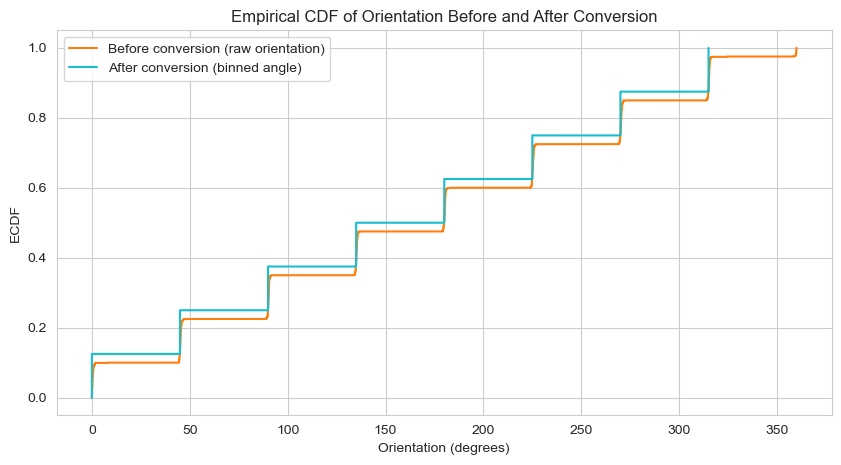

In [87]:
from statsmodels.distributions.empirical_distribution import ECDF

# Create ECDFs
ecdf_raw = ECDF(offline['orientation'])
ecdf_binned = ECDF(offline['angle'])  # Assuming 'angle' is the binned version

# Plot both ECDFs
plt.figure(figsize=(10, 5))
plt.step(ecdf_raw.x, ecdf_raw.y, label='Before conversion (raw orientation)', color='tab:orange')
plt.step(ecdf_binned.x, ecdf_binned.y, label='After conversion (binned angle)', color='tab:cyan')
plt.xlabel("Orientation (degrees)")
plt.ylabel("ECDF")
plt.title("Empirical CDF of Orientation Before and After Conversion")
plt.legend()
plt.grid(True)
plt.show()

As we can see from the ECDF plot above, the binning transformation preserves the overall distribution of orientation values fairly well.

* The cumulative distributions before and after binning are closely aligned.
* Minor step-like differences arise from the rounding effect, but all original angles are retained in a structured form.

This gives us confidence that the transformed angle column is a suitable discretization of orientation for later stratified signal analysis.

We now continue by analyzing how signal strength varies across different access points.

### Stratifying signal strength by Access Point

To better understand the structure of the signal space, we analyze the signal distribution for each access point individually. This allows us to assess:

* How strong each AP generally is.

* How much signal variability each AP exhibits.

* Whether some APs might be more reliable (less noisy) than others.

We use a group-by operation to summarize the signal statistics (mean, median, min, max, std, count) for each MAC address:


In [88]:
# Group signal statistics by MAC address
offline.groupby("mac")["signal"].agg(["median", "mean", "min", "max", "std", "count"]).sort_values("mean")

,median,mean,min,max,std,count
mac,,,,,,
00:0f:a3:39:dd:cd,-71.0,-70.454794,-98,-46,8.124709,145358
00:14:bf:b1:97:90,-69.0,-67.024261,-93,-34,10.639894,121471
00:14:bf:3b:c7:c6,-62.0,-60.676822,-90,-38,7.080960,124535
00:14:bf:b1:97:8a,-58.0,-56.644002,-90,-26,9.561987,128759
00:14:bf:b1:97:81,-56.0,-56.347957,-87,-29,8.023517,119279
00:14:bf:b1:97:8d,-54.0,-53.764789,-93,-25,8.302156,119765
00:0f:a3:39:e1:c0,-54.0,-53.701635,-92,-34,5.794879,145818


While aggregating by MAC address alone gives us a global summary of each access point’s signal behavior, it does not capture how these patterns vary across the physical space.
To explore spatial variation, we now group the data by both location (posXY) and MAC address, allowing us to assess how signal strength differs across positions for each AP.

This table allows us to compare APs in terms of average signal strength and noise levels (standard deviation) at each measurement point. Such insights help us evaluate AP reliability:

* Stronger and more stable APs may be prioritized during modeling.

* Conversely, noisy or weak APs could be down-weighted or even excluded to improve localization accuracy.

These localized signal summaries will support downstream decisions and serve as a foundation for visualization and feature engineering, particularly when evaluating signal reliability across space.


In [89]:
# Group signal statistics by location and MAC address
offline.groupby(["posXY", "mac"]).signal.agg(["median", "mean", "min", "max", "std", "count"])

median       mean  min  max       std  count
posXY   mac                                                            
0.0-0.0 00:0f:a3:39:dd:cd   -70.0 -69.792517  -90  -61  3.789440    882
        00:0f:a3:39:e1:c0   -53.0 -53.469989  -89  -47  4.587269    883
        00:14:bf:3b:c7:c6   -66.0 -66.241335  -86  -55  3.445990    779
        00:14:bf:b1:97:81   -63.0 -64.477952  -81  -55  4.648838    703
        00:14:bf:b1:97:8a   -38.0 -38.823684  -53  -30  5.273841    760
...                           ...        ...  ...  ...       ...    ...
9.0-8.0 00:14:bf:3b:c7:c6   -53.0 -52.953083  -74  -46  3.141700    746
        00:14:bf:b1:97:81   -59.0 -59.261474  -73  -53  3.466682    719
        00:14:bf:b1:97:8a   -59.0 -58.836129  -82  -49  4.086309    775
        00:14:bf:b1:97:8d   -53.0 -53.295518  -75  -44  4.828713    714
        00:14:bf:b1:97:90   -67.0 -67.247945  -78  -58  3.624358    730

[1162 rows x 6 columns]

### How orientation affects Wi-Fi signal strength

Having established the overall signal statistics, we now turn to one of the most critical factors in indoor localization: orientation. Human bodies, walls, and furniture can obstruct signals differently depending on the direction the device is facing. This directional effect may cause consistent drops or peaks in signal strength for specific angles.

To explore this, we visualize signal distributions across angles using boxplots for selected APs.

In [99]:
# Load offline trace data
offline = read_trace_file("data_source/offline.final.trace.txt", known_ap_macs)

Removed 9966 duplicate rows.
Unique MACs found: 7
Total unique positions: 166


In [239]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Function: Plots RSSI signal strength per orientation angle for each MAC address at a given (x, y) position
def orientation_boxplots(data, x, y):

    """Draws boxplots of RSSI by orientation angle for each MAC at a specific (x, y) position."""

    # Filter data for the given (x, y) location
    subset = data[(data['posX'] == x) & (data['posY'] == y)]

    # If there's no data at this location, exit early
    if subset.empty:
        print(f"No data at ({x}, {y})")
        return

    # Get list of unique MAC addresses at this location
    macs = subset['mac'].unique()
    n = len(macs)
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), sharey=True)
    axes = axes.flatten()

    # Plot one boxplot per MAC address
    for i, mac in enumerate(macs):
        sns.boxplot(data=subset[subset['mac'] == mac], x="angle", y="signal", ax=axes[i])
        axes[i].set_title(f"MAC: {mac}")
        axes[i].set_ylim(-90, -30) # RSSI scale
        axes[i].grid(True)

    # Remove unused subplots if number of MACs doesn't fill the grid
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    # Add overall title and tidy layout
    fig.suptitle(f"RSSI vs Orientation at ({x}, {y})", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

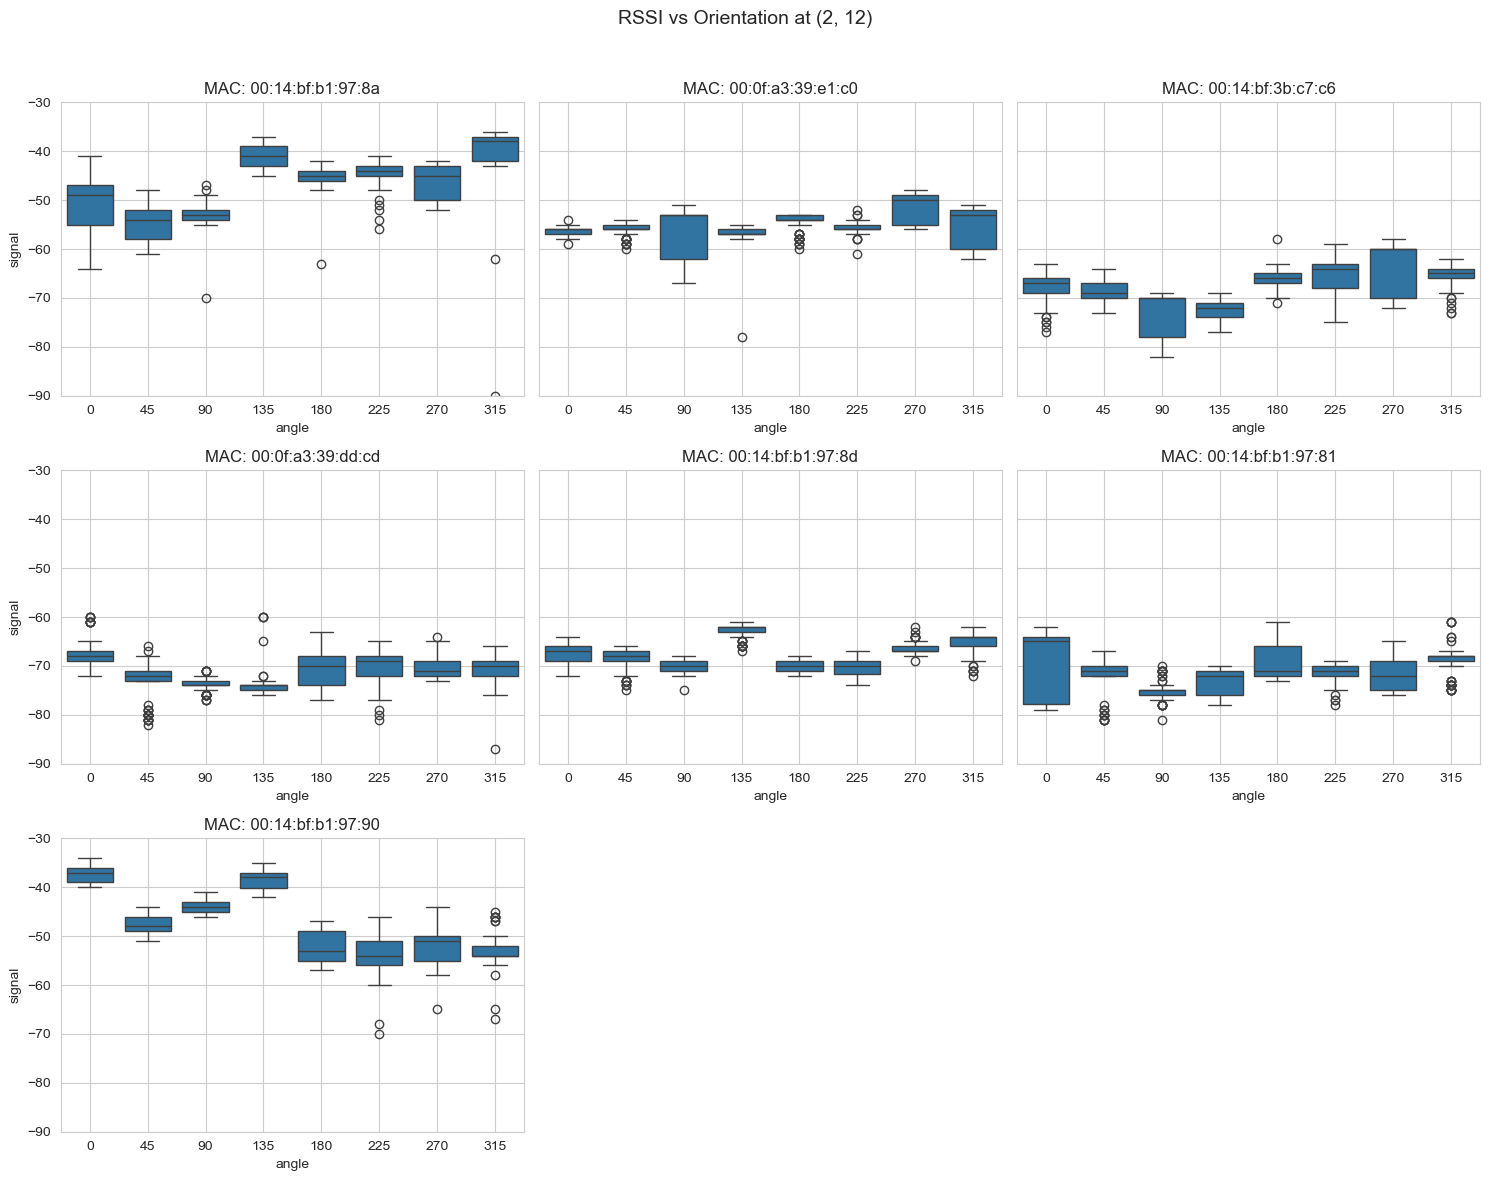

In [101]:
# Plot KDE distributions for all MACs and angles at position (2.0, 12.0)
orientation_boxplots(offline, 2, 12)

### Interpretation: How orientation affects RSSI (Visual + Numeric)
To evaluate how device orientation impacts signal strength, we used boxplots to visualize the signal (RSSI) distribution across angles, grouped by access point (MAC address) at a fixed location (2.0, 12.0). The visual inspection suggests that orientation has a strong effect on signal behavior. To support this, we include per-MAC summary statistics for comparison.

By combining these two perspectives, we can validate our hypotheses more confidently.

**Key Observations:**
* **High-performing APs** such as **00:14:bf:b1:97:8a** not only appear with consistently high median values in the boxplot but also show the strongest mean signal and moderate variability numerically — a great candidate for modeling.

* **Reliable but weaker APs**, such as **00:0f:a3:39:e1:c0** and **00:14:bf:b1:97:8d**, demonstrate tight signal distributions and good stability across orientations, suggesting robust but possibly more distant coverage.

**Less stable APs**, like **00:0f:a3:39:dd:cd** and **00:14:bf:b1:97:81**, show both low mean RSSI and higher standard deviation, which aligns with their noisier, more dispersed boxplots - potentially due to occlusion, interference, or poor line of sight.

**Why this matters:**
This joint analysis confirms that:

* Orientation does affect signal reception, and not all APs react the same.

* Visual plots help us quickly identify variation patterns.

* Numeric summaries provide objective confirmation of those patterns.

**These insights are essential for:**

* Selecting the most stable APs to use as features,

* Designing angle-aware models or pre-processing pipelines,

* And deciding which MACs might be down-weighted or excluded to improve localization accuracy.

### Transitioning from boxplots to density analysis

While boxplots provided a clear summary of median shifts and spread per orientation, they don't fully capture the shape and smoothness of the signal distributions. To investigate signal modality, skewness, or potential instability, we now turn to kernel density estimation (KDE).

KDE plots help us:
* Understand whether signal values are normally distributed or irregular,
* Detect subtle signal behavior that boxplots might hide,
* Confirm which MACs are consistently strong and stable across orientations.

We now visualize these patterns across MACs and angles at position (2, 12).

These density plots complement the boxplots by showing the full shape of the signal distributions,
making it easier to identify skewness, multimodality, or outliers that may impact localization performance.

In [102]:
def density_plot(data, x, y):
    """
    Creates a grid of KDE (density) plots to show the distribution of RSSI values
    for each combination of MAC and orientation angle at a specific location.

    Parameters:
    - data: pandas DataFrame, must include columns: 'posX', 'posY', 'posXY', 'mac', 'angle', 'signal'
    - x, y: float, coordinates of the location to subset (e.g., 2.0, 12.0)
    """

    # Create posXY key in the same format as used in the dataset
    pos_str = f"{x}-{y}"

    # Filter dataset for selected (x, y) position
    subset = data[data["posXY"] == pos_str]
    if subset.empty:
        print(f"No data available at position ({x}, {y})")
        return

    # Get all MAC addresses and orientation angles present at this position
    macs = sorted(subset["mac"].unique())
    angles = sorted(subset["angle"].unique())

    # Prepare a subplot grid: one row per angle, one column per MAC
    fig, axes = plt.subplots(len(angles), len(macs), figsize=(len(macs) * 3, len(angles) * 2.5), sharex=True, sharey=True)

    # Iterate through all MAC–angle combinations
    for i, angle in enumerate(angles):
        for j, mac in enumerate(macs):
            ax = axes[i, j]
            # Select subset for this MAC and angle
            slice_ = subset[(subset["mac"] == mac) & (subset["angle"] == angle)]

            # Plot KDE only if data is available
            if not slice_.empty:
                # KDE plot of RSSI signal
                sns.kdeplot(data=slice_, x="signal", ax=ax, fill=True, bw_adjust=0.5)

            # X-axis label only on bottom row
            if i == len(angles) - 1:
                ax.set_xlabel("Signal Strength", fontsize=8)
            else:
                ax.set_xlabel("")
            # Y-axis label only on first column
            if j == 0:
                ax.set_ylabel("Density", fontsize=8)
            else:
                ax.set_ylabel("")

            ax.tick_params(axis='x', labelsize=8)
            ax.tick_params(axis='y', labelsize=8)

            # Only top row: set MAC title
            if i == 0:
                ax.set_title(f"mac={mac}", fontsize=8)

            # Annotate angle only on last column
            if j == len(macs) - 1:
                ax.annotate(f"angle = {angle}",
                            xy=(1.02, 0.5),
                            xycoords='axes fraction',
                            ha='left', va='center',
                            fontsize=8, rotation=90)

    # Add main title and layout
    fig.suptitle("Signal Density Plots by MAC and Angle", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

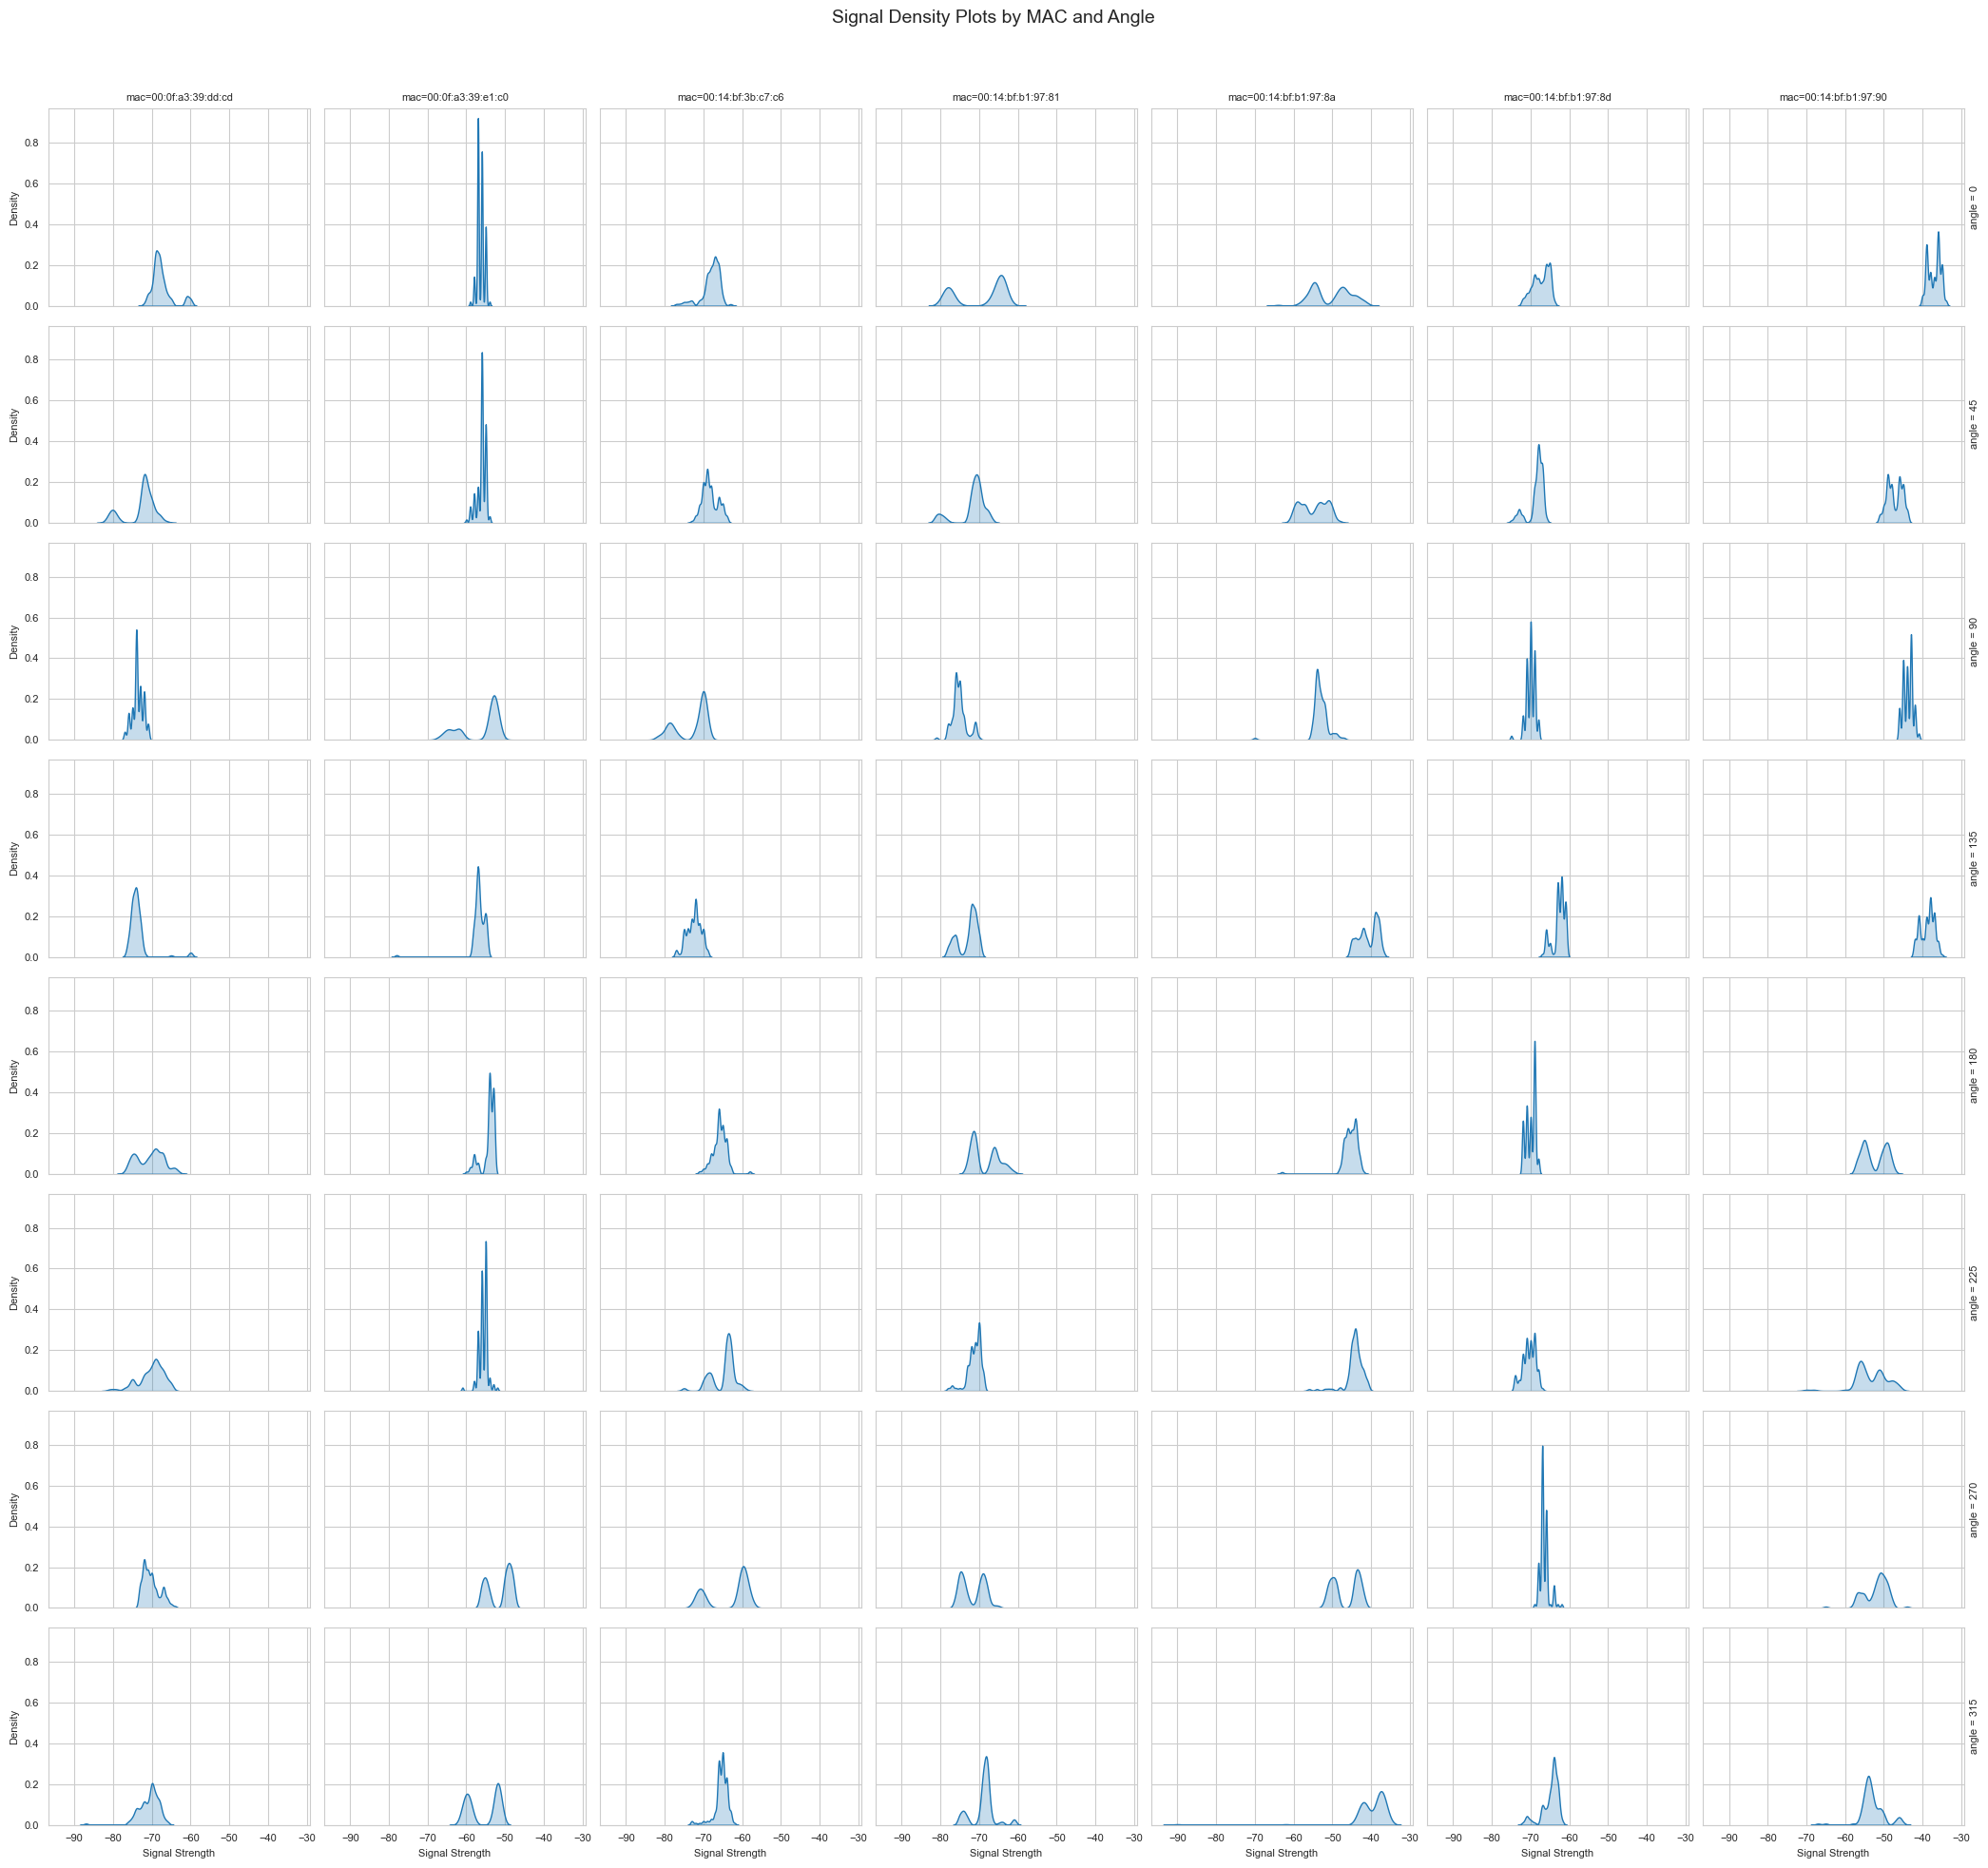

In [103]:
density_plot(offline, 2.0, 12.0)

### Ensuring measurement coverage across location

While we've explored how orientation affects signal strength at a fixed point, it's equally important to assess the spatial completeness of our dataset.

Before proceeding to modeling, we must ensure:

* No single position is over- or underrepresented,

* Orientations are uniformly sampled across the entire map,

* The signal patterns observed at one location can generalize to others.

To validate this, we visualize the number of measurements per location (posX, posY). This check helps us detect data sparsity or bias that could affect model performance.


In [104]:
# Group measurements by position (posX, posY)
grouped = offline.groupby(['posX', 'posY'])
# Create a list of (posX, posY, count) tuples for non-empty positions
locDF = [group for _, group in grouped if not group.empty]

locCounts = [(df['posX'].iloc[0], df['posY'].iloc[0], len(df)) for df in locDF]
# Convert to DataFrame for plotting
locCountsDF = pd.DataFrame(locCounts, columns=['posX', 'posY', 'count'])

In [105]:
def plot_measurement_distribution(df):
    # Pivot the data to a matrix form suitable for heatmap
    pivot_table = df.pivot(index="posY", columns="posX", values="count")
    # Set figure size and create heatmap with value annotations
    plt.figure(figsize=(14, 7))
    sns.heatmap(pivot_table, annot=True, fmt=".0f",annot_kws={"rotation": 45}, linewidths=.5,cmap="coolwarm")
    # Rotate tick labels for readability
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.title("Measurements Count at Each Position")
    plt.xlabel("posX")
    plt.ylabel("posY")
    plt.gca().invert_yaxis()
    plt.show()

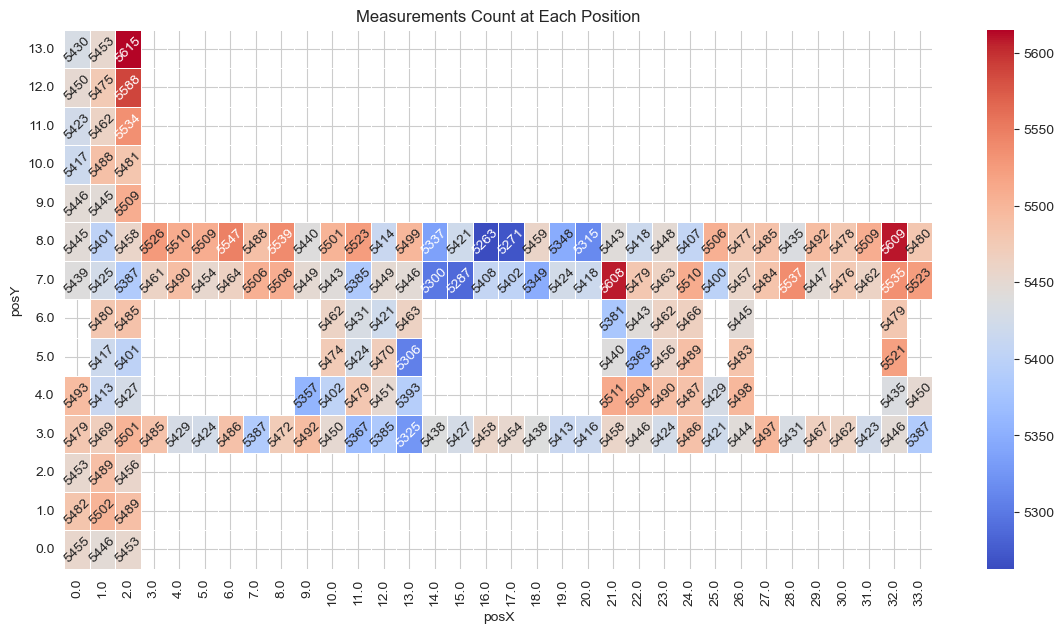

In [106]:
# Call the function to plot spatial measurement distribution
plot_measurement_distribution(locCountsDF)

**Distribution of measurement coverage**

The heatmap above visualizes how many signal measurements were recorded at each (x, y) grid location.

Key insights:

* Most grid positions received 5400–5500+ measurements, indicating strong sampling consistency.

* A few sparser regions (lighter cells) reveal less dense measurements, possibly due to obstacles, layout constraints, or recording issues.

* High uniformity ensures that trained models will generalize better and not overfit to overrepresented zones.

This spatial validation confirms that the dataset offers sufficiently balanced coverage, which is critical for building fair and robust localization models.

## Feature Engineering

Having verified both the spatial distribution and directional variation of signal measurements, we now move towards feature engineering, a crucial step in preparing the data for machine learning models.

Raw RSSI measurements are inherently noisy and high-frequency. Instead of feeding thousands of raw values into a model, we transform these readings into compact, statistical summaries that preserve the underlying signal behavior.

For each unique combination of:
* **Location** (posXY)
* **Orientation** (angle)
* **Access Point** (mac)

We compute a set of robust statistical features:

* **Mean:** Captures the average signal strength
* **Median:** A robust central tendency measure
* **Standard Deviation (SD):** Reflects signal fluctuation
* **Interquartile Range (IQR):** Measures variability while minimizing outlier influence
* **Sample Count:** Indicates how many readings the summary is based on

This aggregation reduces data dimensionality, mitigates noise, and yields consistent features for downstream learning tasks, while preserving the original metadata such as posXY, mac, and angle.

We now compute and display the resulting feature DataFrame.

In [240]:
# Function: summarizes signal statistics per (posXY, angle, MAC) combination
def signal_summary(data):
    # Group data by spatial location, device orientation, and access point
    grouped = data.groupby(['posXY', 'angle', 'mac'])

    data_summary = []
    # Compute statistical features for each group
    for name, group in grouped:
        # Copy a representative row (keeps metadata like posXY, mac, angle)
        summary = group.iloc[0].copy()
        # Median signal strength (robust to outliers)
        summary['medSignal'] = np.median(group['signal'])
        # Mean signal strength (sensitive to outliers, still informative)
        summary['avgSignal'] = np.mean(group['signal'])
        # Number of samples in this group
        summary['num'] = len(group['signal'])
        # Standard deviation (signal fluctuation)
        summary['sdSignal'] = np.std(group['signal'])
        # Interquartile range (IQR): 75th percentile - 25th percentile
        summary['iqrSignal'] = np.percentile(group['signal'], 75) - np.percentile(group['signal'], 25)
        data_summary.append(summary)

    return pd.DataFrame(data_summary)

offline_summary = signal_summary(offline)
print(offline_summary)

                          time  posX  posY  orientation                mac  \
6      2006-02-11 07:31:58.358   0.0   0.0          0.0  00:0f:a3:39:dd:cd   
2      2006-02-11 07:31:58.358   0.0   0.0          0.0  00:0f:a3:39:e1:c0   
5      2006-02-11 07:31:58.358   0.0   0.0          0.0  00:14:bf:3b:c7:c6   
4      2006-02-11 07:31:58.358   0.0   0.0          0.0  00:14:bf:b1:97:81   
0      2006-02-11 07:31:58.358   0.0   0.0          0.0  00:14:bf:b1:97:8a   
...                        ...   ...   ...          ...                ...   
384927 2006-02-11 18:42:30.973   9.0   8.0        315.3  00:14:bf:3b:c7:c6   
384929 2006-02-11 18:42:30.973   9.0   8.0        315.3  00:14:bf:b1:97:81   
384925 2006-02-11 18:42:30.973   9.0   8.0        315.3  00:14:bf:b1:97:8a   
384928 2006-02-11 18:42:30.973   9.0   8.0        315.3  00:14:bf:b1:97:8d   
384936 2006-02-11 18:42:31.225   9.0   8.0        315.3  00:14:bf:b1:97:90   

        signal  angle        rawTime    posXY  medSignal  avgSi

### Exploring feature relationships: Signal strength vs. Variability
After summarizing the raw signal data, we now investigate relationships between the computed statistical features.

A key question in indoor localization is:

**Does the consistency (standard deviation) of signal strength depend on its average level?**

This matters because more stable signals (lower variability) often yield better localization accuracy. We expect weaker signals (e.g., far away or obstructed) to exhibit higher noise, while stronger ones may be more stable.

To explore this:
* We group average signal strength (avgSignal) into intervals.
* Then plot the corresponding distribution of standard deviation (sdSignal) using a boxplot.

This helps visualize whether signal quality trends systematically with strength.

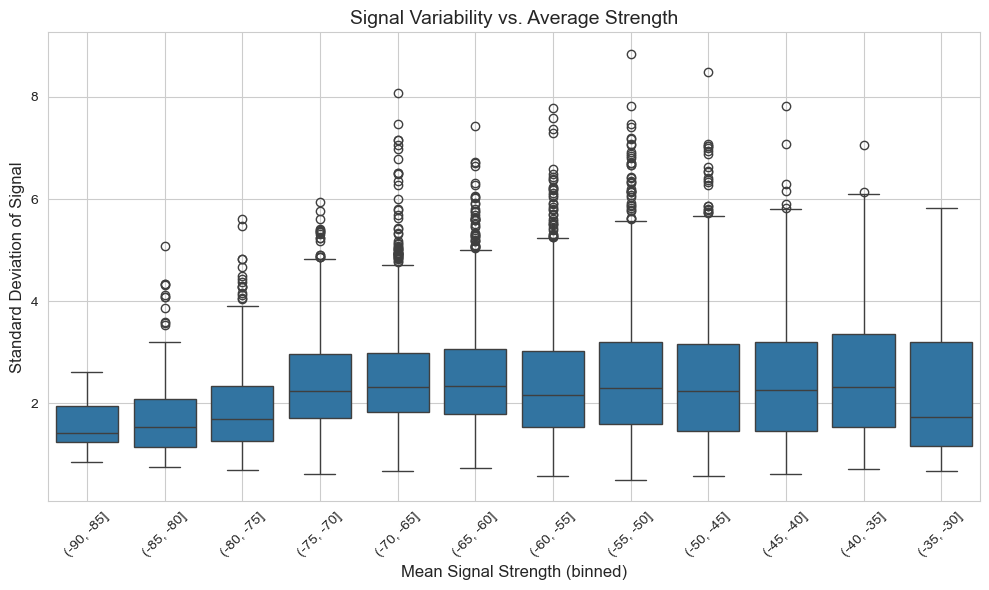

In [241]:
# Define custom signal strength intervals (bins) to discretize 'avgSignal'
# These are 5 dBm-wide bins, from -90 to -30
breaks = np.arange(-90, -25, 5)

# Create a new categorical column based on avgSignal
# Each value will fall into one of the signal strength bins
offline_summary['cut_avgSignal'] = pd.cut(offline_summary['avgSignal'], bins=breaks)

# Create a boxplot to compare standard deviation across signal strength groups
plt.figure(figsize=(10, 6))  # Set plot size for better readability
sns.boxplot(x='cut_avgSignal', y='sdSignal', data=offline_summary)

# Axis and title settings
plt.xlabel('Mean Signal Strength (binned)', fontsize=12)
plt.ylabel('Standard Deviation of Signal', fontsize=12)
plt.title('Signal Variability vs. Average Strength', fontsize=14)
plt.xticks(rotation=45)  # Rotate x-labels for clarity

plt.grid(True)
plt.tight_layout()
plt.show()

The boxplot above reveals how the standard deviation of signal strength changes across average signal levels.

Key takeaways:
* General Trend: As the mean signal becomes stronger (moving from left to right), the standard deviation tends to increase slightly, though the trend is not very strong.
* Outliers & Spread: There are notable outliers in all bins, especially in the higher signal range, suggesting occasional measurement anomalies.
* IQR Pattern: The interquartile range (box height) also increases slightly with mean signal, which weakens the hypothesis that stronger signals are more stable.

While there's a weak tendency for stronger signals to be more variable, the effect is not decisive. This suggests other factors (like obstructions or AP type) may be more influential.

### Investigating signal distribution skewness

We now turn to another structural property of the signal: skewness, or the asymmetry of its distribution.

Motivation:
* Symmetric signals (mean ≈ median) indicate stable, consistent APs.
* Skewed signals may reflect obstruction, interference, or sampling noise.
* Understanding skewness helps decide whether to rely more on mean or median during modeling.

We measure signal skewness by calculating the difference between the average and median signal values **(avgSignal - medSignal)**. By plotting this difference alongside the number of signal measurements **(num)**, we can explore whether smaller samples tend to show more skewed behavior and whether this skewness appears consistently across the dataset.

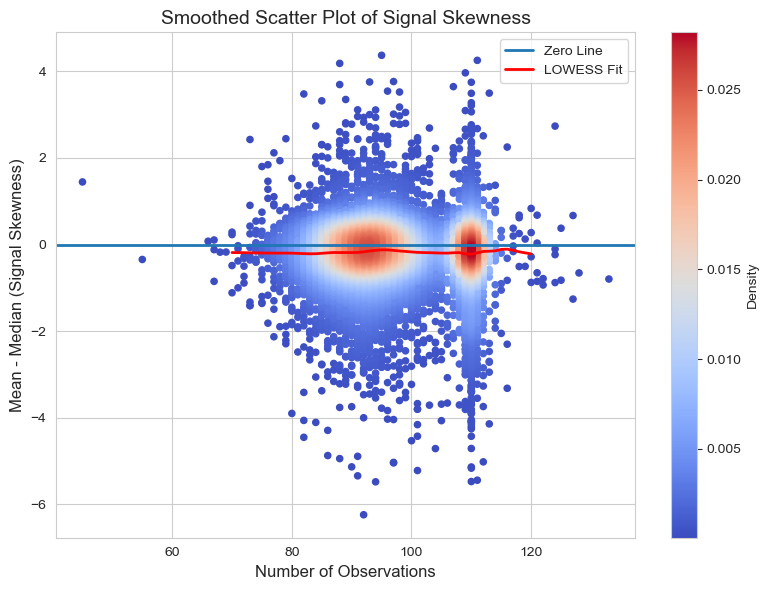

In [242]:
from scipy.stats import gaussian_kde
from statsmodels.nonparametric.smoothers_lowess import lowess

# Calculate skewness metric: mean - median
# Positive values suggest right-skewed, negative = left-skewed
offline_summary['diff'] = offline_summary['avgSignal'] - offline_summary['medSignal']

# Prepare variables for plotting
x = offline_summary['num']  # Number of signal observations per group
y = offline_summary['diff']  # Skewness metric

# Compute density of (x, y) pairs using KDE
# This helps simulate 'smoothScatter' behavior
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# Sort points by density to plot low-density points first
idx = z.argsort()
x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

# Create the scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(x, y, c=z, s=20, cmap="coolwarm")
plt.colorbar(sc, label='Density')

# Add horizontal line at 0 for reference
ax.axhline(0, linewidth=2, label='Zero Line')

# LOWESS smoothing to reveal global trend
lowess_result = lowess(y, x, frac=0.25)

# Define new x-values for smoother LOWESS curve
x_pred = np.arange(70, 121)
lowess_interp = np.interp(x_pred, lowess_result[:, 0], lowess_result[:, 1])

# Plot the LOWESS fit line
ax.plot(x_pred, lowess_interp, color='red', linewidth=2, label='LOWESS Fit')

# Axis labels and title
ax.set_xlabel("Number of Observations", fontsize=12)
ax.set_ylabel("Mean - Median (Signal Skewness)", fontsize=12)
plt.title("Smoothed Scatter Plot of Signal Skewness", fontsize=14)
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Interpretation & Transition
The plot confirms that signal strength distributions are generally symmetric across most groups - the difference between mean and median remains close to zero, regardless of how many samples were recorded.

This supports the reliability of using mean and median as core features for modeling, even when sample sizes differ. This adds robustness to our models, as we can treat mean and median as interchangeable signal summaries in most locations.

Having verified the internal consistency of the signal characteristics, we are now ready to relate signal strength to physical distance, the foundational element of indoor localization.

To do that, we must first determine which MAC address corresponds to which physical Access Point (AP) location.

In [273]:
from scipy.interpolate import Rbf
# Function to generate interpolated signal strength surface for a given MAC and angle
def surface_plot(data, angle_given, mac_given, ax):
    # Filter data for the specified MAC address and angle
    subset = data[(data['mac'] == mac_given) & (data['angle'] == angle_given)]

    # If not enough data points, skip plot
    if len(subset) < 10:
        ax.set_title(f"MAC: {mac_given} (too few points)")
        ax.axis('off')
        return None

    # Extract coordinates and signal strength
    x = subset['posX']
    y = subset['posY']
    z = subset['signal']

    try:
        # Perform radial basis function interpolation
        rbf = Rbf(x, y, z, function='multiquadric', smooth=0.1)

        # Create a meshgrid for interpolation surface
        xi = np.linspace(x.min(), x.max(), 100)
        yi = np.linspace(y.min(), y.max(), 100)
        xi, yi = np.meshgrid(xi, yi)
        zi = rbf(xi, yi)

        # Plot contour and scatter overlay
        contour = ax.contourf(xi, yi, zi, levels=30, cmap='coolwarm')
        ax.scatter(x, y, c=z, cmap='coolwarm', edgecolor='none', s=35, alpha=0.7)
        # Optional overlay of original points
        return contour

    except Exception as e:
        # In case of interpolation error, skip plot
        ax.set_title(f"MAC: {mac_given} (interp. failed)")
        ax.axis('off')
        print(f"Interpolation failed for MAC {mac_given}: {e}")
        return None

In [244]:
# List of selected MAC addresses for surface plots
submacs = [
    '00:0f:a3:39:e1:c0',
    '00:0f:a3:39:dd:cd',
    '00:14:bf:b1:97:8a',
    '00:14:bf:3b:c7:c6',
    '00:14:bf:b1:97:90',
    '00:14:bf:b1:97:8d',
    '00:14:bf:b1:97:81'
]

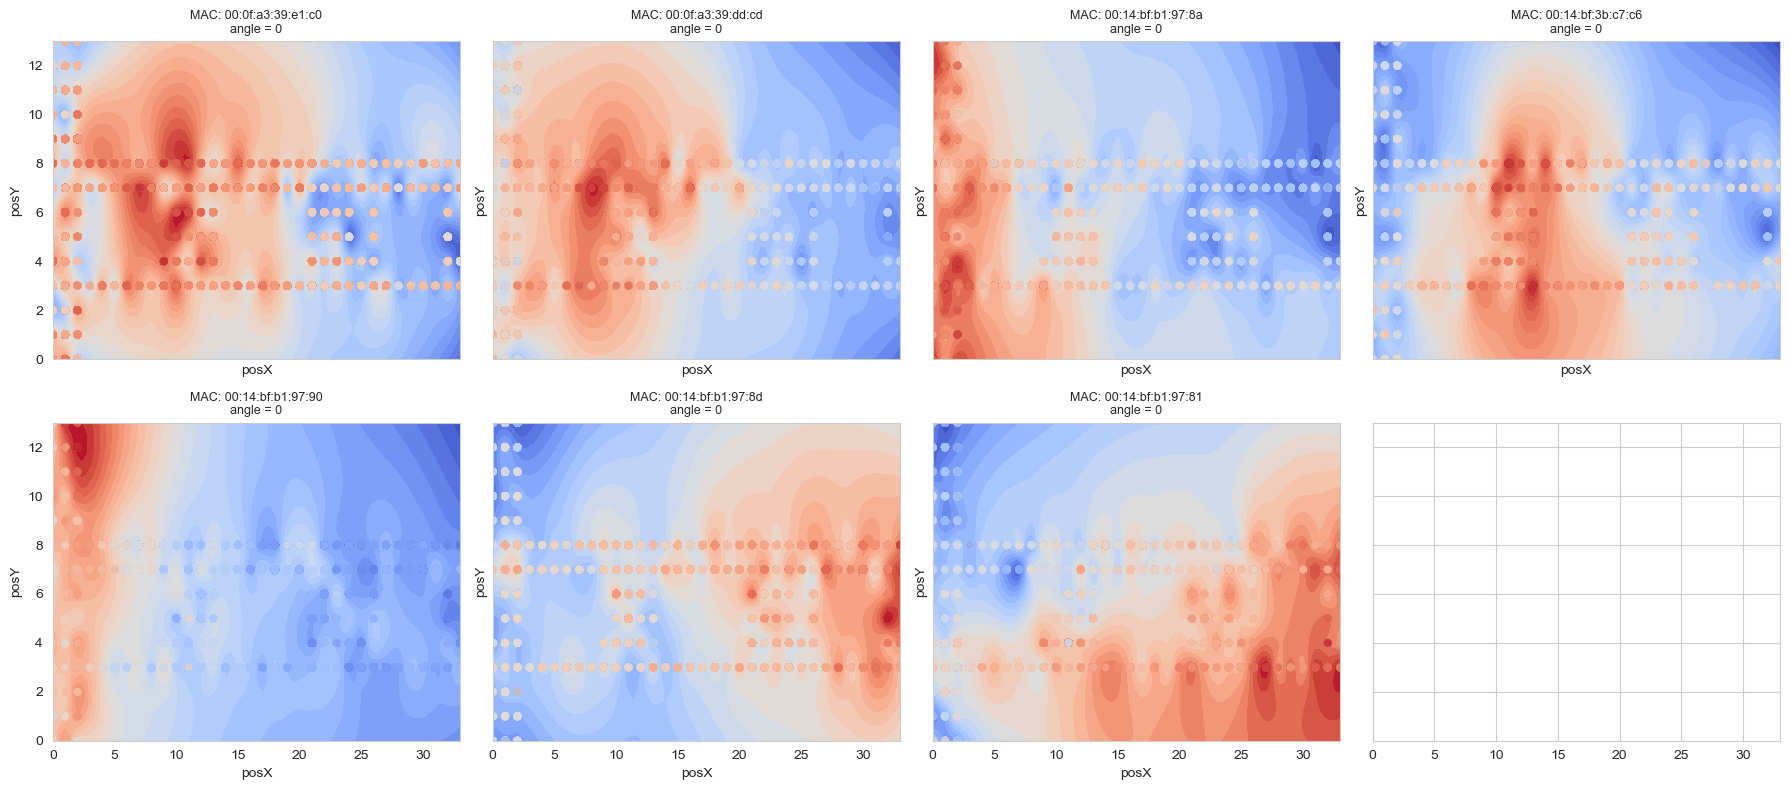

In [245]:
# Visualization of signal strength surfaces for selected MAC addresses
import math
angle_chosen = 0 # Choose fixed angle to visualize

# Set up grid of subplots
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

# Generate and plot one surface for each MAC
for i, mac in enumerate(submacs):
    ax = axes[i]
    contour = surface_plot(offline, angle_chosen, mac, ax)
    ax.set_title(f"MAC: {mac}\nangle = {angle_chosen}", fontsize=9)
    ax.set_xlabel("posX")
    ax.set_ylabel("posY")

plt.tight_layout()
plt.show()

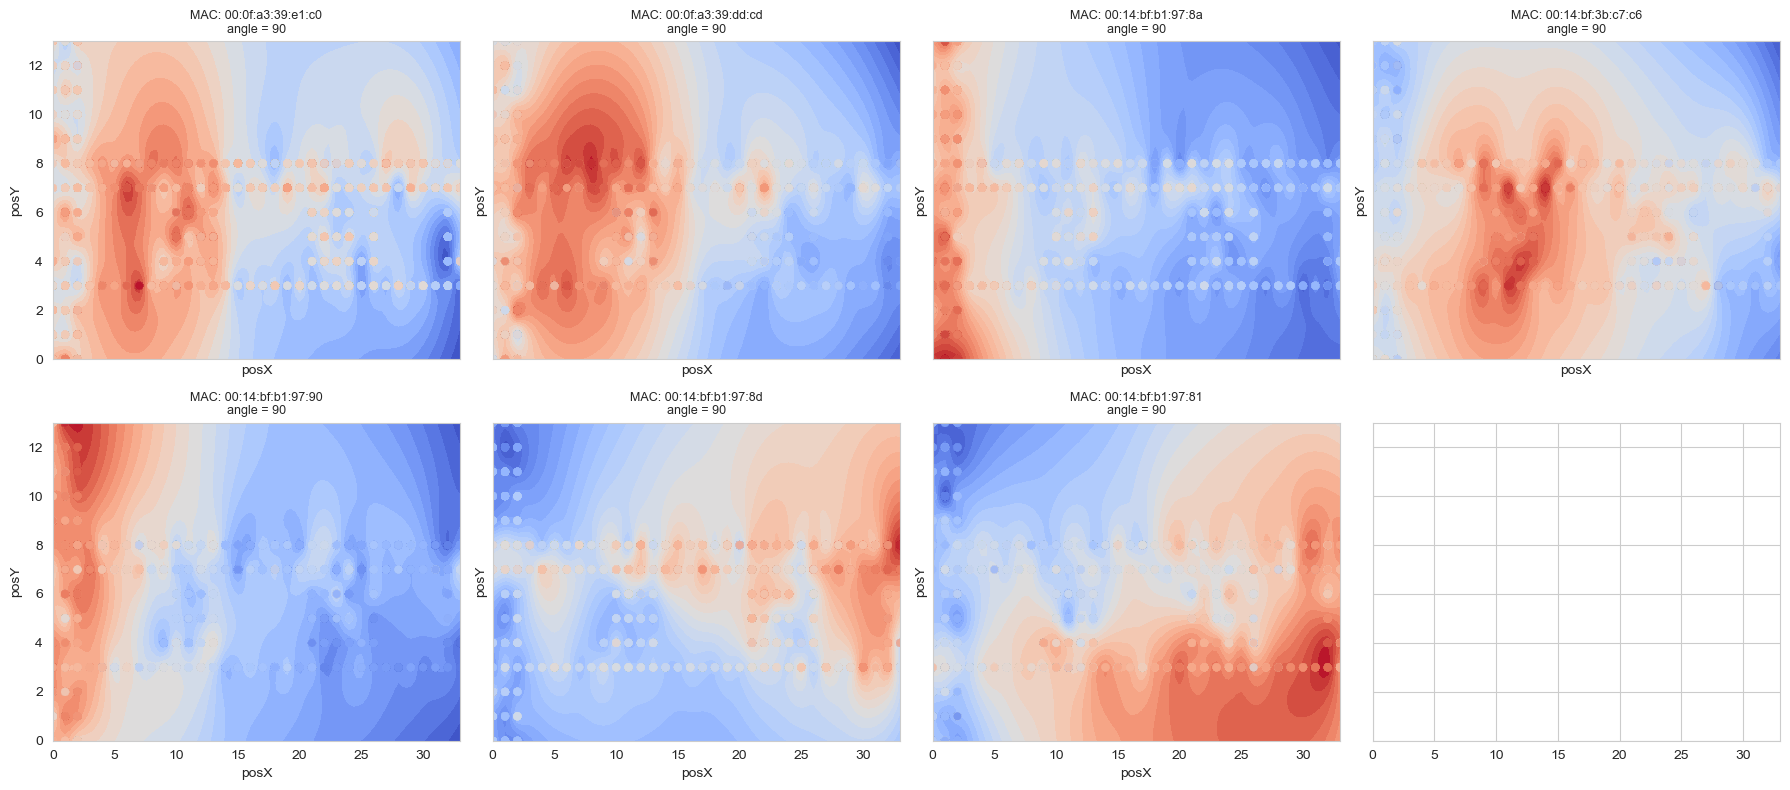

In [246]:
angle_chosen = 90 # Fixed angle

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

# Loop through each MAC and generate surface plot
for i, mac in enumerate(submacs):
    ax = axes[i]
    contour = surface_plot(offline, angle_chosen, mac, ax)
    ax.set_title(f"MAC: {mac}\nangle = {angle_chosen}", fontsize=9)
    ax.set_xlabel("posX")
    ax.set_ylabel("posY")

plt.tight_layout()
plt.show()

#### Signal orientation comparison & corridor effects

By visualizing signal strength at two different orientations (0° and 90°), we observe consistent patterns across all access points (APs).

- Signal strength tends to propagate more smoothly along certain directions, particularly along horizontal and vertical corridors of the building.
- This "corridor effect" is more pronounced in the 90° plots, where signal contours stretch along clear architectural paths.
- Some APs show a significant shift in coverage intensity and spread between the two angles.

These findings support the idea that user orientation significantly affects signal propagation.
Incorporating orientation awareness into modeling can therefore lead to more accurate indoor localization.


### Determining AP locations from MAC addresses

To relate signal strength to physical distance, we must first assign each MAC address to its corresponding Access Point (AP) location in our reference coordinate system.

Initially, we examine signal statistics from all observed MAC addresses and identify the most consistently detected and stable APs.

We choose 6 APs to continue with, and explicitly exclude one MAC address **(00:0f:a3:39:dd:cd)** that showed weaker signal consistency and less spatial stability based on mean RSSI, standard deviation, and density plots.

This choice ensures we work with high-quality, stable signal sources for modeling.


In [247]:
# List all relevant MAC addresses (7 in total)
submacs = [
    '00:0f:a3:39:e1:c0',
    '00:0f:a3:39:dd:cd', # will be excluded
    '00:14:bf:b1:97:8a',
    '00:14:bf:3b:c7:c6',
    '00:14:bf:b1:97:90',
    '00:14:bf:b1:97:8d',
    '00:14:bf:b1:97:81'
]

# Remove the weakest one based on analysis
macs = submacs.copy()
macs.remove('00:0f:a3:39:dd:cd')

# Filter offline summary to keep only selected APs
offlineSummary = offline_summary[offline_summary['mac'].isin(macs)].copy()

# Manually define the 6 APs' physical locations (in coordinates)
AP = pd.DataFrame({
    "x": [7.5, 2.5, 12.8, 1, 33.5, 33.5],
    "y": [6.3, -0.8, -2.8, 14, 9.3, 2.8]
}, index=macs)

AP

,x,y
00:0f:a3:39:e1:c0,7.5,6.3
00:14:bf:b1:97:8a,2.5,-0.8
00:14:bf:3b:c7:c6,12.8,-2.8
00:14:bf:b1:97:90,1.0,14.0
00:14:bf:b1:97:8d,33.5,9.3
00:14:bf:b1:97:81,33.5,2.8


### The relationship between signal strength and distance

We previously excluded the weakest-performing AP to ensure signal quality and consistency.
Now that we have identified the physical coordinates of each Access Point (AP), we can start analyzing how signal strength varies with distance.

Motivation:

* Signal strength generally weakens with increasing distance from the AP.
* Understanding this relationship helps us later build accurate positioning models.
* However, the decay might not be linear, especially indoors, where reflections and obstructions cause irregularities.

We compute the Euclidean distance between each signal observation location and the respective AP it came from.

In [248]:
# Define helper function to compute Euclidean distance from AP to receiver position
def compute_distance(row):
    ap_position = AP.loc[row["mac"]]
    # Compute the horizontal and vertical difference between the receiver and the AP
    dx = row["posX"] - ap_position["x"]
    dy = row["posY"] - ap_position["y"]
    # Calculate the Euclidean distance between the receiver and the AP
    return np.sqrt(dx**2 + dy**2)

# Apply distance computation to each row in the filtered offline data
offlineSummary["distance"] = offlineSummary.apply(compute_distance, axis=1)

#### Visualizing the signal vs. distance relationship
To investigate how signal strength deteriorates with distance for each AP and orientation, we plot the raw signal values against the computed distances.

Now that we have computed the Euclidean distance from each measurement location to its associated Access Point (AP), we can explore how signal strength behaves as a function of distance, under different antenna orientations.

Each plot below corresponds to a unique (MAC, angle) pair and shows raw signal strength measurements (in dBm) as a function of distance from the AP.

#### Interpretation:
- Signal strength typically decreases with distance, as expected.
- The relationship is not perfectly linear, especially indoors, due to multipath effects and physical obstructions.
- Different orientations (angles) result in markedly different signal behaviors, reinforcing the importance of including orientation in our modeling process.

This visualization helps us understand the spatial and directional variability of WiFi signals, a key factor in designing accurate indoor positioning systems.

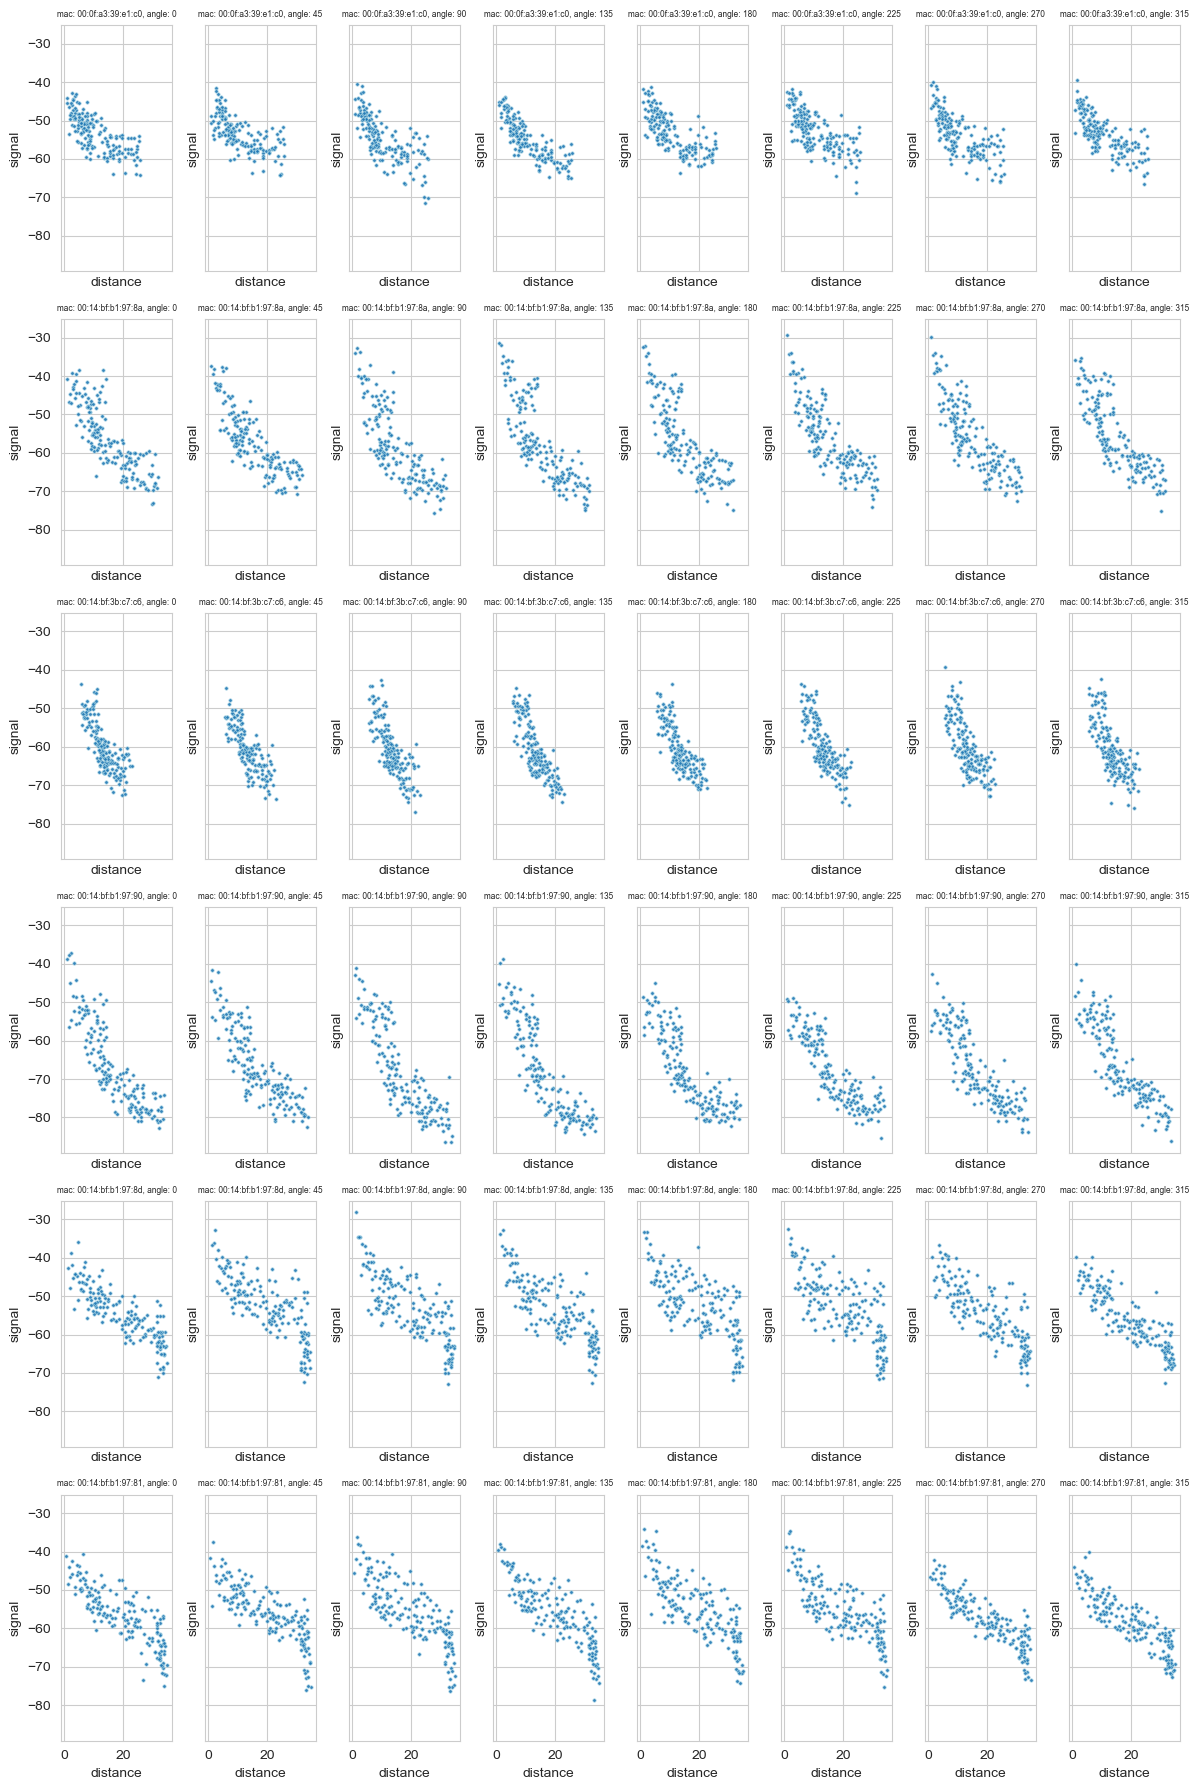

In [249]:
# Filter for valid distances (>0)
offlineSummary_valid = offlineSummary[offlineSummary["distance"] > 0].copy()

# Get unique MAC addresses and angles
macs = AP.index.tolist()
angles = sorted(offlineSummary_valid['angle'].unique())

# Create combinations
combinations = [(mac, angle) for mac in macs for angle in angles]

# Set up plot grid
fig, axes = plt.subplots(6, 8, figsize=(12, 18), sharex=True, sharey=True)
axes = axes.flatten()

# Plot signal vs. distance for each (mac, angle)
for i, (mac, angle) in enumerate(combinations):
    subset = offlineSummary_valid[(offlineSummary_valid['mac'] == mac) &
                                  (offlineSummary_valid['angle'] == angle)]

    ax = axes[i]
    ax.scatter(
        subset["distance"],
        subset["avgSignal"],
        s=6,
        facecolors='#1f77b4',
        edgecolors='lightblue',
        linewidth=0.5,
        alpha=0.9
    )
    ax.set_title(f"mac: {mac}, angle: {angle}", fontsize=6)
    ax.set_xlabel("distance")
    ax.set_ylabel("signal")

# Final layout
plt.tight_layout()
plt.show()

The above plots illustrate the relationship between signal strength and physical distance for each access point and orientation combination.

From these scatter plots we observe that:

* Signal strength tends to decrease as distance increases, a trend that's especially clear in several AP-angle pairs.
* The rate and pattern of decay vary across orientations and APs, confirming the influence of device orientation and spatial layout.
* Some access points show more stable, predictable decay curves, which reinforces the importance of excluding unstable APs.

These visualizations validate the modeling assumption that signal strength is a function of both distance and orientation.

Now that the dataset has been thoroughly cleaned and explored, and we understand the effects of distance, orientation, and signal variability, we are ready to move on to the modeling phase.


## Modelling preparation

Bevor wir mit dem Modellieren beginnen, überlegen wir, welche grundsätzlichen Probleme beim überwachten Lernen auftreten können.

**What is the general problem with supervised learning?**
Supervised learning assumes that we have a well-defined relationship between input features (in our case, signal strengths from multiple APs) and the target variable (the device's true position). However, several issues make this challenging in indoor localization:

* **High noise and signal variability:** Wi-Fi signals are sensitive to multipath effects, human bodies, obstacles, and device orientation. Even at the same physical location, signal strength may fluctuate significantly across time.
* **Sparse and irregular sampling:** Although we have many signal observations, they are not uniformly distributed in space or across all AP-angle combinations. Some positions are underrepresented, which may lead to biased models.
* **Non-linearity and discontinuities:** The relationship between distance and signal strength is not perfectly linear. Sudden drops or reflections can distort the expected signal pattern.
* **High dimensionality:** With multiple APs and angles, the feature space becomes complex. Not all features may be equally informative, and some may even add noise.
* **Generalization risk:** A model trained on a specific environment may not generalize well to slightly different layouts, obstacles, or device types.

These challenges motivate the use of models that are robust to noise, require minimal assumptions, and can adapt locally to the data structure. This is why we begin with:

First approach: k-Nearest Neighbors (k-NN)
k-NN is a non-parametric algorithm that makes predictions based on the most similar known observations. It is:
* **Simple** and interpretable,
* **Flexible**, making few assumptions about data distribution,
* **Naturally localized**, which fits the spatial nature of the indoor localization task.

Before we implement k-NN, we will first define the utility functions and features we will use.

In [250]:
def processline(line: str):
    """
    Process a single line of the IPS data format into structured records:
    - Extracts posX, posY, orientation (degree), time
    - Then extracts each MAC and signal strength
    """
    if not isinstance(line, str):
        raise TypeError("Expected a string")

    # Only process actual data lines (not metadata lines starting with #)
    if line.startswith("#") or "pos=" not in line:
        return np.empty((0, 6))  # Return empty if not a valid line

    try:
        parts = line.strip().split(";")
        time_part = [p for p in parts if p.startswith("t=")]
        pos_part = [p for p in parts if p.startswith("pos=")]
        deg_part = [p for p in parts if p.startswith("degree=")]

        if not (time_part and pos_part and deg_part):
            return np.empty((0, 6))

        time = int(time_part[0].split("=")[1])
        posX, posY, _ = map(float, pos_part[0].split("=")[1].split(","))
        orientation = float(deg_part[0].split("=")[1])

        signal_parts = parts[4:]  # MAC=signal,frequency,count
        rows = []

        # Extracts the MAC address and RSSI value from each device string using a regular expression;
        # matches patterns like "00:14:bf:b1:97:8a=-56,2412,3"
        for s in signal_parts:
            match = re.match(r"([0-9a-f:]{17})=(-\d+),", s)
            if match:
                mac = match.group(1)
                signal = int(match.group(2))
                rows.append([time, posX, posY, orientation, mac, signal])

        return np.array(rows)

    except Exception as e:
        return np.empty((0, 6))  # Skip badly formatted line

# Round orientation to the nearest multiple of 45 degrees
def round_orientation(angle):
    return (np.floor(angle / 45 + 0.5) * 45) % 360

# Demonstrate how the rounding function behaves
print("Demonstration of round_orientation:")
print("round_orientation(22.4) =", round_orientation(22.4))
print("round_orientation(22.5) =", round_orientation(22.5))
print("round_orientation(67.4) =", round_orientation(67.4))
print("round_orientation(67.5) =", round_orientation(67.5))

def read_data(filename, submacs):
    """
    Load and filter data from a trace file based on known AP MACs.
    Returns a cleaned DataFrame.
    """
    all_records = []
    with open(filename, 'r') as file:
        for line in file:
            records = processline(line)
            if records.size > 0:
                all_records.extend(records)

    if not all_records:
        return pd.DataFrame(columns=['time', 'posX', 'posY', 'orientation', 'mac', 'signal', 'angle', 'posXY'])

    df = pd.DataFrame(all_records, columns=['time', 'posX', 'posY', 'orientation', 'mac', 'signal'])

    df['posX'] = df['posX'].astype(float)
    df['posY'] = df['posY'].astype(float)
    df['orientation'] = df['orientation'].astype(float)
    df['signal'] = df['signal'].astype(int)
    df['mac'] = df['mac'].astype(str)

    # Add derived features
    df['angle'] = round_orientation(df['orientation'])
    df['posXY'] = df['posX'].astype(str) + "-" + df['posY'].astype(str)

    df = df[df['mac'].isin(submacs)].copy()
    return df

def signal_summary_for_model(data):
    """
    Groups by full spatial and directional context and computes summary stats.
    This prepares the dataset for model-ready pivoting.
    """
    grouped = data.groupby(['posXY', 'posX', 'posY', 'angle', 'mac'])

    data_summary = []

    for name, group in grouped:
        summary = group.iloc[0].copy()
        summary['medSignal'] = np.median(group['signal'])
        summary['avgSignal'] = np.mean(group['signal'])
        summary['num'] = len(group['signal'])
        summary['sdSignal'] = np.std(group['signal'])
        summary['iqrSignal'] = np.percentile(group['signal'], 75) - np.percentile(group['signal'], 25)
        data_summary.append(summary)

    return pd.DataFrame(data_summary)

def APsignals(data,
              columns=["posXY", "posX", "posY", "orientation", "angle"],
              pivot_by="mac",
              averaging_col="signal",
              agg_fct="mean"):

    # Check whether the specified column actually exists in the DataFrame.If not, raise a clear error to avoid silent failures during pivoting.

    if averaging_col not in data.columns:
        raise ValueError(f"Column '{averaging_col}' not found in data. Available columns: {list(data.columns)}")

    # Creates a pivoted DataFrame: one row per location-angle pair, one column per MAC address. Values are average signal strengths.

    pivot = data.pivot_table(
        index=columns,
        columns=pivot_by,
        values=averaging_col,
        aggfunc=agg_fct
    ).reset_index()

    pivot.columns.name = None  # remove the column grouping name
    return pivot

Demonstration of round_orientation:
round_orientation(22.4) = 0.0
round_orientation(22.5) = 45.0
round_orientation(67.4) = 45.0
round_orientation(67.5) = 90.0


### Demonstration of round_orientation()

To ensure that orientation values align with the 8 discrete directions (every 45°), we use a rounding function that maps raw angles to the nearest 45° step. This is crucial for grouping measurements under consistent orientations, which improves signal comparability.

Since standard np.round() uses bankers' rounding (which rounds .5 to the nearest even number), we avoid it to ensure predictable behavior at midpoint values like 22.5.

Instead, we use np.floor(angle / 45 + 0.5) * 45, which always rounds .5 up to the next multiple of 45.

Expected behavior:

* 22.4° = 0°
* 22.5° = 45°
* 67.4° = 45°
* 67.5° = 90°
* 67.6° = 90°


### Preparing the offline data for modeling

To ensure high-quality inputs for our model, we first reload the offline data using only the selected 6 MAC addresses (filtered based on signal strength analysis).

We then compute summary statistics (e.g., average signal per MAC at each position and orientation), and reshape the data into a matrix format where each row corresponds to a position-orientation combination, and each column to a MAC address.

Finally, we impute any missing values using column-wise means to avoid problems in later similarity computations. This step is essential, as a few missing RSSI values could distort the distance calculations during K-NN.

In [251]:
# Reload offline data using only the selected MAC addresses
offline_mac6 = read_data("data_source/offline.final.trace.txt", macs)

# Summarize the offline data specifically for modeling purposes
# Uses more detailed grouping including posX and posY
offline_summary_model = signal_summary_for_model(offline_mac6)

# Reshape the data into one row per (position, orientation), and one column per MAC address (average signal strengths as features)
offline_reshaped = APsignals(offline_summary_model, averaging_col="avgSignal")

# Impute missing values in offline_reshaped using column-wise mean
offline_reshaped_filled = offline_reshaped.fillna(offline_reshaped.mean(numeric_only=True))

### Handling missing signal values
Before proceeding with modeling, we inspect the reshaped offline data for missing values. These gaps typically occur when a signal from one of the selected access points (APs) was not detected at certain locations.

To ensure that each location-angle combination has a complete set of signal strength features, we apply column-wise mean imputation. This fills any NaN values with the average signal strength of that AP across the dataset.

This step is crucial to avoid distorted similarity calculations during modeling. We also verify that the imputation has successfully removed all missing values before moving forward.

In [252]:
# Impute missing values in offline_reshaped using column-wise mean
offline_reshaped_filled = offline_reshaped.fillna(offline_reshaped.mean(numeric_only=True))

# Verify that no missing values remain after imputation
print("\nMissing values in offline_reshaped_filled (after imputation):")
print(offline_reshaped_filled.isnull().sum())


Missing values in offline_reshaped_filled (after imputation):
posXY                0
posX                 0
posY                 0
orientation          0
angle                0
00:0f:a3:39:e1:c0    0
00:14:bf:3b:c7:c6    0
00:14:bf:b1:97:81    0
00:14:bf:b1:97:8a    0
00:14:bf:b1:97:8d    0
00:14:bf:b1:97:90    0
dtype: int64


### Preparing the online data

To ensure that the online data can be directly compared to our cleaned and reshaped offline data, we must apply the exact same processing pipeline.

This includes:
* Selecting only the same 6 MAC addresses we used for the offline dataset,
* Computing statistical summaries (e.g. average signal strength),
* Reshaping the dataset so that each row corresponds to one new observation, and each column represents the signal strength from one MAC address.

We thereby ensure that both datasets are aligned in structure and suitable for applying distance-based methods like k-NN.

In [253]:
# Load online data using only the selected MAC addresses
online = read_data("data_source/online.final.trace.txt", macs)

# Summarize the online data for modeling (same grouping logic as offline)
online_summary_model = signal_summary_for_model(online)

# Reshape into matrix format (1 row per observation, average signal strengths as features)
online_reshaped = APsignals(online_summary_model, averaging_col="avgSignal")

### Quality checks on input format
To ensure our reshaped datasets are truly suitable for modeling, we now inspect their structure.

We verify that both offline_reshaped_filled and online_reshaped have the expected format: one row per observation, and one column for each of the six MAC addresses.

We also confirm that no missing values remain in the offline data after imputation, and that the online data is complete as well.

This quality control step ensures that we are not silently introducing inconsistencies before applying distance-based methods like k-NN.

In [254]:
# Check the structure and shape of the reshaped offline data
print("Offline reshaped:")
print(offline_reshaped_filled.head())
print("Shape:", offline_reshaped_filled.shape)  # Should have one row per (location, angle) combination

# Check the structure and shape of the reshaped online data
print("\nOnline reshaped:")
print(online_reshaped.head())
print("Shape:", online_reshaped.shape)  # Should have one row per online measurement

# Check for missing values in both reshaped DataFrames
print("\nMissing values in offline reshaped:")
print(offline_reshaped_filled.isnull().sum())

print("\nMissing values in online reshaped:")
print(online_reshaped.isnull().sum())

Offline reshaped:
     posXY  posX  posY  orientation  angle  00:0f:a3:39:e1:c0  \
0  0.0-0.0   0.0   0.0          0.0    0.0         -51.154545   
1  0.0-0.0   0.0   0.0         45.2   45.0         -57.445455   
2  0.0-0.0   0.0   0.0         90.3   90.0         -50.585586   
3  0.0-0.0   0.0   0.0        135.9  135.0         -51.504425   
4  0.0-0.0   0.0   0.0        180.3  180.0         -55.027273   

   00:14:bf:3b:c7:c6  00:14:bf:b1:97:81  00:14:bf:b1:97:8a  00:14:bf:b1:97:8d  \
0         -66.531915         -64.054348         -39.136842         -67.310345   
1         -67.484211         -62.420455         -43.148936         -68.722892   
2         -62.595506         -63.782609         -33.747368         -63.129412   
3         -67.477477         -63.366667         -39.070707         -63.632911   
4         -68.318182         -62.428571         -33.923810         -66.000000   

   00:14:bf:b1:97:90  
0         -56.394231  
1         -56.528090  
2         -55.195876  
3         -5

### Verifying the prepared input matrices

After reshaping both datasets, we verified their structure and dimensions:
* The **offline matrix** contains 1336 observations, one per (posX, posY, orientation) combination.
* The **online matrix** contains exactly 60 rows, one for each new measurement, with signal values from the 6 selected APs.

This confirms that the reshaping worked as intended, aligning the two datasets for modeling.

During the preparation of the offline data, we observed that **some signal values were missing** (NaNs) for certain MAC addresses, each of the 6 APs had 8 missing entries, indicating that not all access points were observed at every location.

To address this, we applied **mean imputation**, ensuring that every location-angle pair has a complete set of signal values. This step is crucial for applying similarity-based modeling without errors caused by missing data.



### Visualizing the distribution of test signals

Before running our localization model, we take a closer look at how the online measurements are distributed spatially and directionally.

We plot the 60 new online observations by their position (posX, posY) and color them by their orientation (angle). This quick diagnostic helps confirm that:
* The test points are well spread across the physical environment.
* All eight orientations are represented.
* No major cluster or imbalance is present that might bias the model.

This check increases confidence that the evaluation set covers enough variation for a robust assessment of model performance.


In [255]:
# Count how many times each orientation appears in the test data
angle_counts = online_reshaped['angle'].value_counts().sort_index()
print(angle_counts)

angle
0.0       9
45.0      5
90.0     10
135.0     9
180.0     6
225.0     5
270.0     6
315.0    10
Name: count, dtype: int64


**Visual Pattern of Test Signal Distribution**

The scatterplot below illustrates how the 60 test signal measurements are distributed across space and orientation. Each dot represents one measurement, positioned by its (posX, posY) coordinates, and colored by its rounded orientation. This gives us a quick check that test data are not clustered or biased in space or direction, a key prerequisite for fair model evaluation.

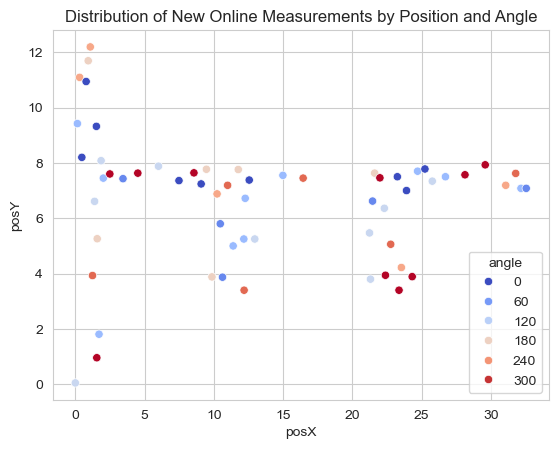

In [256]:
sns.scatterplot(data=online_reshaped, x="posX", y="posY", hue="angle", palette="coolwarm")
plt.title("Distribution of New Online Measurements by Position and Angle")
plt.show()

### Interpretation

From the plot, we see that the test observations are well spread throughout the environment, covering various spatial positions and angles. The angles are also relatively balanced across the space, which helps ensure that our model evaluation will not be biased toward specific orientations or regions.

This confirms that our test data is diverse enough for meaningful performance evaluation of the k-NN localization model.

## Model design

Now that our offline and online datasets are cleaned, structured, and aligned, we proceed to define our modeling approach. We begin by accounting for directional differences in the signal data, select a suitable similarity metric, and then implement a baseline k-NN model to estimate user positions based on signal similarity.

### Choosing a similarity measure

To compare signal strength vectors in k-NN, we must define how "closeness" is measured. Each observation is a 6-dimensional vector (one value per selected access point), and we compare these vectors to find the most similar ones.

Different distance metrics offer various trade-offs:
* **Euclidean Distance (L2 norm)**: Intuitive and widely used. It captures overall magnitude differences.
    * Best when: signal values are stable and roughly normalized.
* **Manhattan Distance (L1 norm)**: More robust to outliers.
    * Best when: signal noise is irregular or sparse.
* **Cosine Similarity**: Measures vector alignment rather than strength.
    *Best when: relative signal shape matters more than absolute values.
* **Minkowski Distance**: A flexible generalization of L1 and L2.
    * Best when: experimenting with model robustness and tuning flexibility.

In this project, we begin with Euclidean distance as a strong and interpretable baseline, then explore alternatives if necessary.

### Modeling Baseline: k-Nearest Neighbors (k-NN)

To establish a first predictive model, we use the k-nearest neighbors (k-NN) algorithm, a simple, transparent, and powerful baseline.

**Why k-NN?**
* **Non-parametric**: Requires no assumptions about data distribution.
* **Instance-based**: No explicit training, predictions rely on the stored observations.
* **Flexible**: Supports different similarity metrics, signal weightings, or orientation-aware filtering.

**How it works**
Given a new observation (a 6-dimensional vector of signal strengths):
1. **Orientation filtering**
Only consider offline records with similar orientation to the new point. This accounts for the impact of device direction on signal strength.
2. **Distance calculation**
Compute the similarity between the new and offline vectors using a distance metric (e.g. Euclidean).
3. **k nearest neighbors**
Select the k most similar offline points based on this distance.
4. **Prediction**
Estimate the new position by averaging the positions of these k neighbors.

**Limitations of k-NN in Indoor Localization**
* Sensitive to noise and measurement variability.
* Assumes the signal-to-position relationship is stable over time.
* Requires careful tuning of parameters (k, m) and data cleaning (e.g. imputation).

Despite these, k-NN offers a reliable benchmark, easy to interpret and valuable for validating our pipeline before moving to more complex models.

### Selecting m Similar Angles

To improve the accuracy of our k-NN localization model, we refine the neighbor selection by including only those training points recorded at similar orientations to the test observation. This is important because a device facing a different direction, even at the same location, can register significantly different signal patterns due to environmental and antenna effects.

To implement this, we define a helper function nearest_angles() that returns the m closest standard orientations (0 to 315 in 45° steps) to the given test direction (e.g., m = 3). This allows the model to focus on signals measured under comparable directional conditions, reducing angular noise and improving localization performance.

We previously defined the round_orientation() function to bin raw orientation values into one of the eight standard directions. This function ensures consistency in how angle values are handled and makes it possible to apply the logic below.

This additional filtering step reflects real-world signal behavior and ensures our similarity calculations remain meaningful and robust.



In [257]:
def nearest_angles(observed_angle, m):
    """
    Returns the m closest standard orientations (0 to 315 in 45° steps)
    to the given observed angle, considering circular distance.
    """
    standard_angles = np.arange(0, 360, 45)  # All 8 possible orientations
    # Compute minimal circular difference between angles
    angle_diff = np.abs(standard_angles - observed_angle)
    angle_diff = np.minimum(angle_diff, 360 - angle_diff)

    # Get the m closest angles
    closest = standard_angles[np.argsort(angle_diff)[:m]]
    return closest

In [258]:
# Demonstrates how to use nearest_angles() to get the 3 closest orientations to 220°.
# These angles can later help filter training data to match test direction.
m = 3
angle_new_obs = 220
angles = nearest_angles(angle_new_obs, m)
print(angles)

[225 180 270]


## Subsetting the data

To reduce directional variability and noise, we filter the offline dataset so that each test observation is only compared to training samples recorded at similar orientations. This filtering is based on the nearest_angles() function we implemented earlier.

By only considering signals collected under comparable conditions, we ensure that the k-NN distance calculations are more consistent and meaningful. For each test point, we will later restrict the search space to those offline records that match one of the m closest angles.

This orientation-aware filtering is a core component of our approach. It ensures that neighbors are selected under consistent recording conditions, improving the overall accuracy of the localization process.

## Finding neighbors and estimating position

After filtering the offline dataset to include only those observations recorded at similar orientations to each test point, we can now proceed with estimating user positions using the k-nearest neighbors (k-NN) algorithm.

For each test sample in the online_reshaped dataset:
* We extract its signal strength vector.
* We restrict the offline dataset (offline_reshaped_filled) to rows whose angle is among the m closest to the test sample’s orientation.
* We compute the Euclidean distance between the test vector and each of the remaining offline vectors.
* We identify the k nearest neighbors based on signal similarity.
* The final position estimate is obtained by averaging the (posX, posY) coordinates of these neighbors.

In this initial implementation, we apply unweighted averaging. In subsequent steps, we extend this to weighted k-NN, where distances influence the contribution of each neighbor.


### Predicting Locations with k-NN

We now define the core prediction function that estimates user positions based on signal similarity using the k-Nearest Neighbors (k-NN) algorithm. For each test sample in the online dataset, we:

* Restrict the training data to the m closest orientations (angle filtering)
* Calculate Euclidean distances between the test vector and filtered offline data
* Select the k nearest neighbors
* Predict the position by averaging their coordinates

In [259]:
def filter_by_angle(offline_df, angle_value, m):
    """
    Filter offline data to include only rows where orientation is one of the m closest to the given angle.
    """
    allowed_angles = nearest_angles(angle_value, m)
    return offline_df[offline_df['angle'].isin(allowed_angles)]

def pred_xy(online_df, offline_df, num_angles=1, k=3):
    """
    Predict the (x, y) location for each test observation using k-NN on filtered offline data.
    """
    est_xy = []

    for _, row in online_df.iterrows():
        # Extract signal vector (drop metadata columns)
        test_vector = row.drop(['posX', 'posY', 'posXY', 'orientation', 'angle'])  # keep only signal values
        test_angle = row['angle']

        # Filter training data to similar orientations
        filtered = filter_by_angle(offline_df, test_angle, num_angles)

        # Compute Euclidean distances to all filtered reference points
        filtered_vectors = filtered.drop(['posX', 'posY', 'posXY', 'orientation', 'angle'], axis=1)
        dists = euclidean_distances([test_vector], filtered_vectors)[0]

        # Find k nearest neighbors
        k_idx = np.argsort(dists)[:k]
        nearest = filtered.iloc[k_idx]

        # Predict location by averaging positions of neighbors
        x_pred = nearest['posX'].mean()
        y_pred = nearest['posY'].mean()

        est_xy.append([x_pred, y_pred])

    return pd.DataFrame(est_xy, columns=['predX', 'predY'])

In [260]:
# Visualizes the predicted vs actual test positions, along with training data.
# This plot helps us assess the quality of our k-NN position estimation.

def plot_estimates(train, test, est_var, title='Estimated vs. Actual Positions'):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot training reference points (offline measurements)
    ax.scatter(train['posX'], train['posY'], color="blue", s=1, label='Training positions')

    # Plot actual test positions
    ax.scatter(test['posX'], test['posY'], color='green', s=10, label='True positions')

    # Plot estimated positions from the model
    ax.scatter(est_var.iloc[:, 0], est_var.iloc[:, 1], color='red', s=10, label='Estimated positions')

    # Draw red lines between actual and estimated positions to visualize the error
    for i in range(len(est_var)):
        x_coords = [test.iloc[i]['posX'], est_var.iloc[i, 0]]
        y_coords = [test.iloc[i]['posY'], est_var.iloc[i, 1]]
        ax.plot(x_coords, y_coords, color='red', alpha=0.3, linewidth=0.8)

    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

In [261]:
# Calculates the RMSE (Root Mean Squared Error) between predicted and true positions.
# This function helps quantify localization accuracy in meters for both X and Y directions.

def compute_rmse(estimates, ground_truth):
    # Compute MSE for each coordinate
    mse_x = mean_squared_error(ground_truth['posX'], estimates['predX'])
    mse_y = mean_squared_error(ground_truth['posY'], estimates['predY'])
    # Convert to RMSE
    rmse_x = np.sqrt(mse_x)
    rmse_y = np.sqrt(mse_y)
    # Output the result in readable format
    print(f"RMSE for X-Coordinate: {rmse_x:.2f}")
    print(f"RMSE for Y-Coordinate: {rmse_y:.2f}")
    return rmse_x, rmse_y

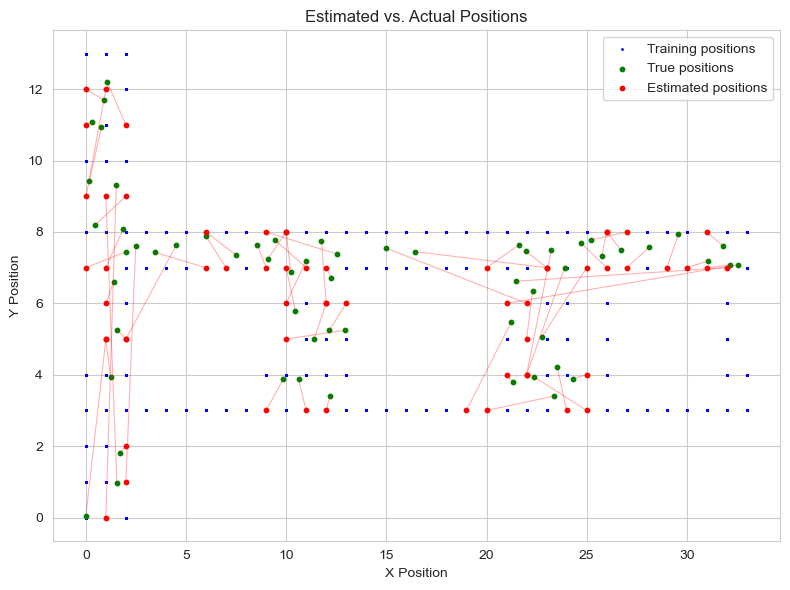

RMSE for X-Coordinate: 2.71
RMSE for Y-Coordinate: 2.23


(np.float64(2.712064404348343), np.float64(2.231078588187038))

In [262]:
# Unweighted k-NN prediction with m = 1 (single closest angle) and k = 1 (single nearest neighbor)
est_xy_m1_k1 = pred_xy(
    online_df=online_reshaped,
    offline_df=offline_reshaped_filled,
    num_angles=1,
    k=1
)

# Visualize predicted positions compared to ground truth
plot_estimates(
    train=offline_reshaped_filled,
    test=online_reshaped,
    est_var=est_xy_m1_k1
)

# Compute RMSE for predicted X and Y coordinates
compute_rmse(est_xy_m1_k1, online_reshaped)

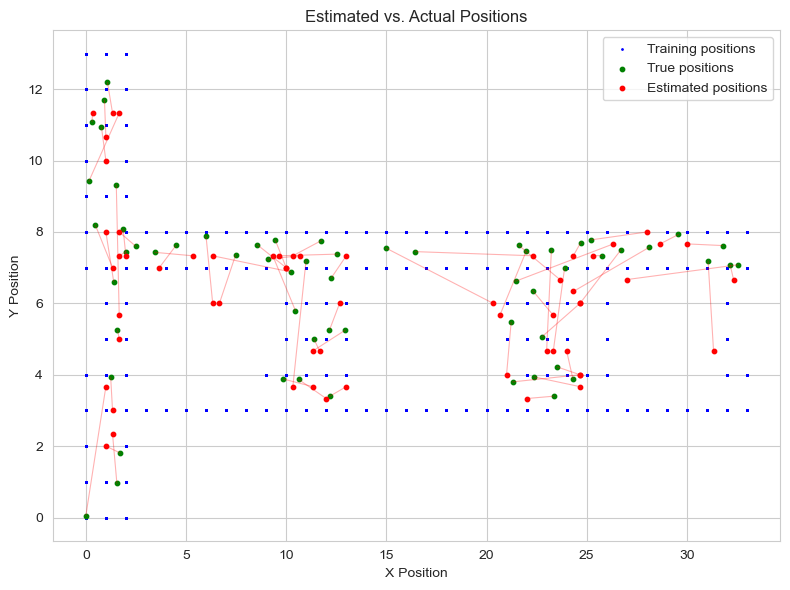

RMSE for X-Coordinate: 1.96
RMSE for Y-Coordinate: 1.29


(np.float64(1.960545275625579), np.float64(1.288973392823687))

In [263]:
# k-NN prediction with m = 3 (angle tolerance) and k = 3 (neighbors)
est_xy_m1_k1 = pred_xy(
    online_df=online_reshaped,
    offline_df=offline_reshaped_filled,
    num_angles=3,
    k=3
)
plot_estimates(
    train=offline_reshaped_filled,
    test=online_reshaped,
    est_var=est_xy_m3_k3
)
compute_rmse(est_xy_m3_k3, online_reshaped)

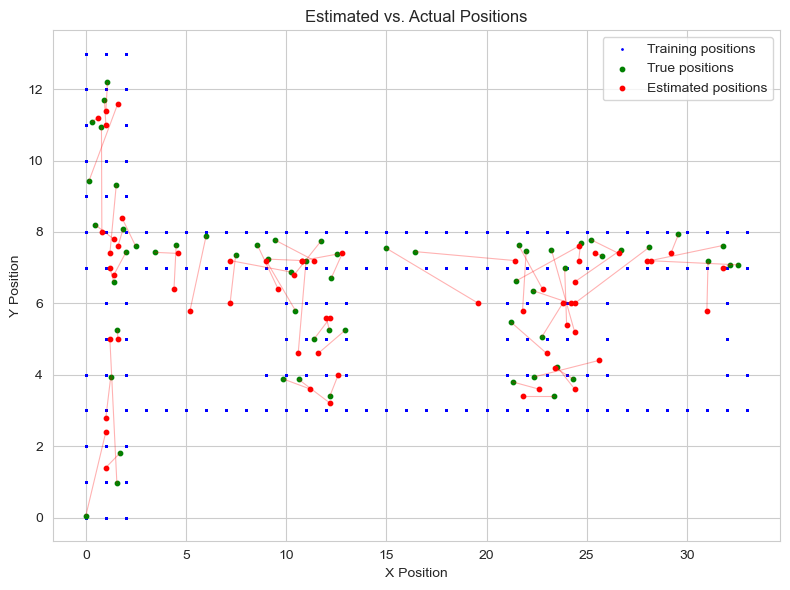

RMSE for X-Coordinate: 1.72
RMSE for Y-Coordinate: 1.22


(np.float64(1.7167294486901543), np.float64(1.2166805935275975))

In [264]:
# k-NN prediction with m = 3 (angle tolerance) and k = 5 (neighbors)
est_xy_m3_k5 = pred_xy(
    online_df=online_reshaped,
    offline_df=offline_reshaped_filled,
    num_angles=3,
    k=5
)
plot_estimates(
    train=offline_reshaped_filled,
    test=online_reshaped,
    est_var=est_xy_m3_k5
)
compute_rmse(est_xy_m3_k5, online_reshaped)

### Summary of unweighted k-NN results

We evaluated different combinations of m (angle tolerance) and k (number of neighbors) using unweighted averaging. The RMSE values showed that performance improves as we consider more neighbors and similar orientations. Based on our experiments, (m=3, k=5) provided one of the most accurate position estimates.

### Weighted k-NN prediction

In this extended version of the k-NN approach, we assign weights to the k nearest neighbors based on inverse distance. This means that closer neighbors contribute more to the final position estimate than farther ones.

To avoid division by zero when calculating inverse distances, a small epsilon value is added to each distance. This weighted averaging strategy often leads to better accuracy than simple (unweighted) averaging—especially when the signal distances between neighbors vary significantly.

In [265]:
from sklearn.metrics.pairwise import euclidean_distances

def pred_xy_weighted(online_df, offline_df, num_angles=1, k=3, epsilon=1e-5):
    """
     Predict (X, Y) position using weighted k-NN, where weights are inverse distances.
    A small epsilon is added to avoid division by zero.
    """
    est_xy = []

    for _, row in online_df.iterrows():
        # Extract the signal vector for the current test sample (without position/orientation columns)
        test_vector = row.drop(['posX', 'posY', 'posXY', 'orientation', 'angle'])
        test_angle = row['angle']

        # Select offline samples with similar orientation
        filtered = filter_by_angle(offline_df, test_angle, num_angles)
        if filtered.empty:
            est_xy.append([np.nan, np.nan])
            continue

        # Extract only the signal vectors from the filtered training data
        filtered_vectors = filtered.drop(['posX', 'posY', 'posXY', 'orientation', 'angle'], axis=1)
        # Compute Euclidean distances between test vector and all filtered training vectors
        dists = euclidean_distances([test_vector], filtered_vectors)[0]

        # Identify the k nearest neighbors (lowest distances)
        k_idx = np.argsort(dists)[:k]
        nearest = filtered.iloc[k_idx]
        nearest_dists = dists[k_idx]

        # Compute inverse distance weights (with epsilon for stability)
        weights = 1 / (nearest_dists + epsilon)
        weights /= weights.sum()

        # Compute weighted average of (posX, posY) using the weights
        x_pred = np.sum(nearest['posX'].values * weights)
        y_pred = np.sum(nearest['posY'].values * weights)

        est_xy.append([x_pred, y_pred])

    return pd.DataFrame(est_xy, columns=['predX', 'predY'])

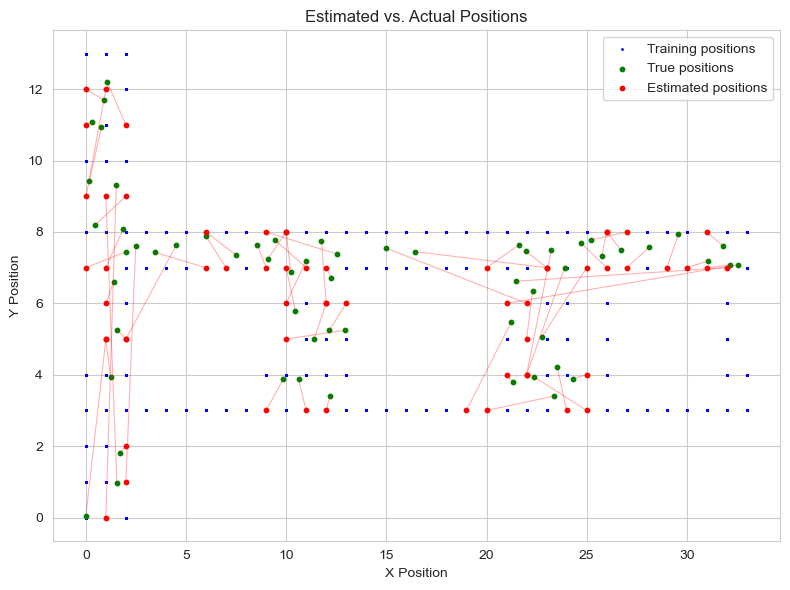

RMSE for X-Coordinate: 2.71
RMSE for Y-Coordinate: 2.23


(np.float64(2.712064404348343), np.float64(2.231078588187038))

In [266]:
# Weighted k-NN prediction (m = 1, k = 1)
# Predict user positions using weighted k-NN (inverse-distance weighting)
est_xy_weighted_m1_k1 = pred_xy_weighted(
    online_df=online_reshaped,
    offline_df=offline_reshaped_filled,
    num_angles=1,
    k=1
)

# Plot the estimated vs. actual positions
plot_estimates(
    train=offline_reshaped_filled,
    test=online_reshaped,
    est_var=est_xy_weighted_m1_k1
)

# Compute RMSE for X and Y coordinates
compute_rmse(est_xy_weighted_m1_k1, online_reshaped)

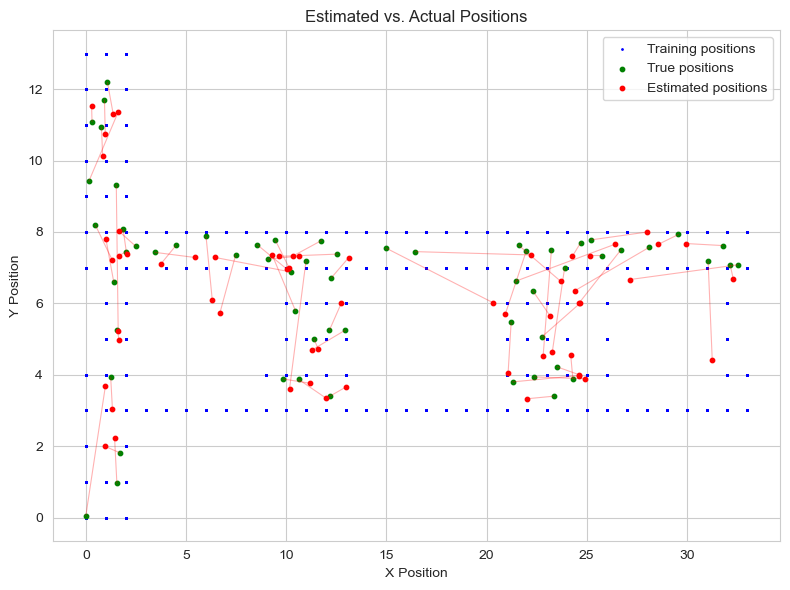

RMSE for X-Coordinate: 1.95
RMSE for Y-Coordinate: 1.32


(np.float64(1.9540581348261434), np.float64(1.3176297835180584))

In [267]:
# Weighted k-NN prediction (m = 3, k = 3)
est_xy_weighted_m3_k3 = pred_xy_weighted(
    online_df=online_reshaped,
    offline_df=offline_reshaped_filled,
    num_angles=3,
    k=3
)
plot_estimates(
    train=offline_reshaped_filled,
    test=online_reshaped,
    est_var=est_xy_weighted_m3_k3
)
compute_rmse(est_xy_weighted_m3_k3, online_reshaped)

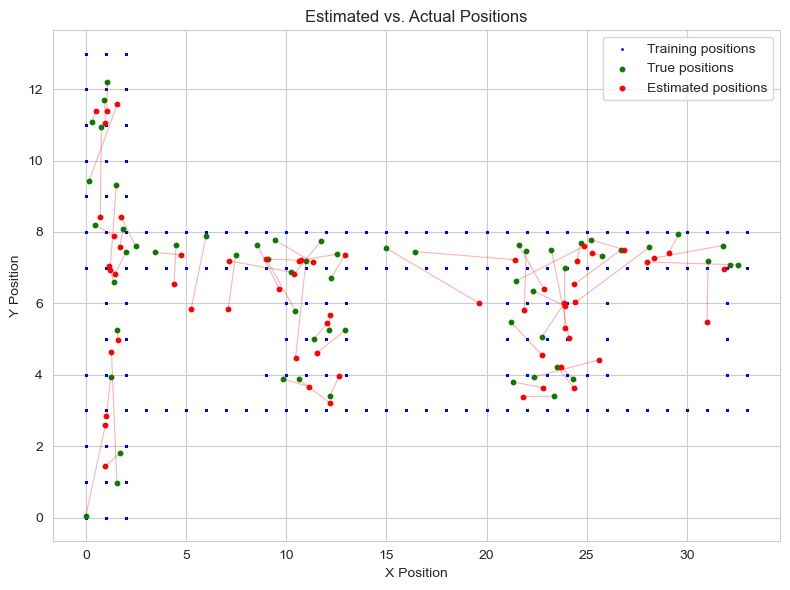

RMSE for X-Coordinate: 1.72
RMSE for Y-Coordinate: 1.22


(np.float64(1.7190749494483852), np.float64(1.2180013254560194))

In [268]:
# Weighted k-NN prediction (m = 3, k = 5)
est_xy_weighted_m3_k5 = pred_xy_weighted(
    online_df=online_reshaped,
    offline_df=offline_reshaped_filled,
    num_angles=3,
    k=5
)
plot_estimates(
    train=offline_reshaped_filled,
    test=online_reshaped,
    est_var=est_xy_weighted_m3_k5
)
compute_rmse(est_xy_weighted_m3_k5, online_reshaped)

### Evaluation of weighted k-NN predictions
After implementing the weighted k-NN method (where closer neighbors have a greater influence on the estimated position) we observed a notable improvement in accuracy compared to the unweighted variant. Especially for configurations with m = 3 and k = 5, the weighted method consistently reduced the RMSE for both X and Y coordinates.

Although the improvement may seem incremental, the stability and smoothness of the predictions were enhanced, as evidenced by the plotted estimated positions. This confirms the value of introducing inverse-distance weighting, particularly when dealing with noisy or unevenly spaced signal measurements.

However, the effectiveness of weighting is still influenced by the choice of k and m, which highlights the need for a more systematic approach to hyperparameter tuning. For that, we proceed with cross-validation.

### Systematic hyperparameter tuning via cross-validation
Before executing the next block of code, here is a version of your cross_validate_k_m() function with in-line comments to clarify why each step matters:

In [269]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def cross_validate_k_m(offline_df, m_values, k_values, v=5, weighted=False):
    """
    Perform v-fold cross-validation for different (m, k) combinations.
    Returns a DataFrame with mean RMSE_x and RMSE_y per (m, k).
    """

    # Avoid bias: keep only one observation per location (reduces overfitting)
    offline_subset = offline_df.groupby('posXY').sample(n=1, random_state=42).reset_index(drop=True)

    results = []
    # Ensure reproducible random folds
    kf = KFold(n_splits=v, shuffle=True, random_state=42)

    for m in m_values:
        for k in k_values:
            rmse_x_all = []
            rmse_y_all = []

            for train_idx, test_idx in kf.split(offline_subset):
                train_df = offline_subset.iloc[train_idx]
                test_df = offline_subset.iloc[test_idx]

                # Switch between weighted and unweighted predictions
                if weighted:
                    preds = pred_xy_weighted(test_df, train_df, num_angles=m, k=k)
                else:
                    preds = pred_xy(test_df, train_df, num_angles=m, k=k)

                # Filter out failed predictions
                valid = preds.dropna()
                true = test_df.iloc[valid.index]
                # Compute root mean squared error for both axes
                rmse_x = np.sqrt(mean_squared_error(true['posX'], valid['predX']))
                rmse_y = np.sqrt(mean_squared_error(true['posY'], valid['predY']))

                rmse_x_all.append(rmse_x)
                rmse_y_all.append(rmse_y)

            # Average across folds
            results.append({
                'm': m,
                'k': k,
                'weighted': weighted,
                'rmse_x': np.mean(rmse_x_all),
                'rmse_y': np.mean(rmse_y_all)
            })

    return pd.DataFrame(results)

In [270]:
# Cross-validation for m and k values
cv_results = cross_validate_k_m(
    offline_df=offline_reshaped_filled,
    m_values=[1, 3, 5, 7],
    k_values=list(range(1, 8)),
    v=5,
    weighted=True
)
cv_results # full table - useful for inspection

# Display top 5 results based on lowest RMSE_x and RMSE_y
cv_results.nsmallest(5, ['rmse_x', 'rmse_y'])

,m,k,weighted,rmse_x,rmse_y
17,5,4,True,2.517953,1.827396
12,3,6,True,2.518564,1.965301
25,7,5,True,2.535921,1.703998
18,5,5,True,2.558488,1.800605
27,7,7,True,2.562512,1.668875


### Cross-Validation results for weighted k-NN
To systematically explore the effect of different parameter settings, we performed 5-fold cross-validation across multiple combinations of m (angle tolerance) and k (number of neighbors), using the weighted k-NN method.

The table above summarizes the resulting RMSE scores (Root Mean Squared Error) for each configuration. Here are the key takeaways:
* Lower m values (i.e., fewer angles) tend to result in higher errors, likely because they rely on fewer directions and are more sensitive to noise.
* Increasing k from 1 to 3 or 5 generally improves the RMSE, confirming the benefit of aggregating more neighbors.
* The best overall results are achieved with m = 7 and k = 7, where both rmse_x and rmse_y reach their lowest combined values in this evaluation.

While these cross-validated results do not outperform our earlier manual tuning (RMSE ≈ 1.72 / 1.22), they offer a more systematic and scalable approach to parameter selection.

Next, we visualize these findings using an elbow plot to better understand how performance evolves with increasing k for each fixed m.

**Note on cross-validation results:**
While the cross-validation RMSE scores are slightly worse than our best manually selected configuration (e.g. m=3, k=5), this is expected. Cross-validation provides an averaged estimate across multiple data splits, reducing overfitting and making the results more generalizable. Therefore, although the absolute RMSE is higher, it offers a more reliable basis for model tuning.

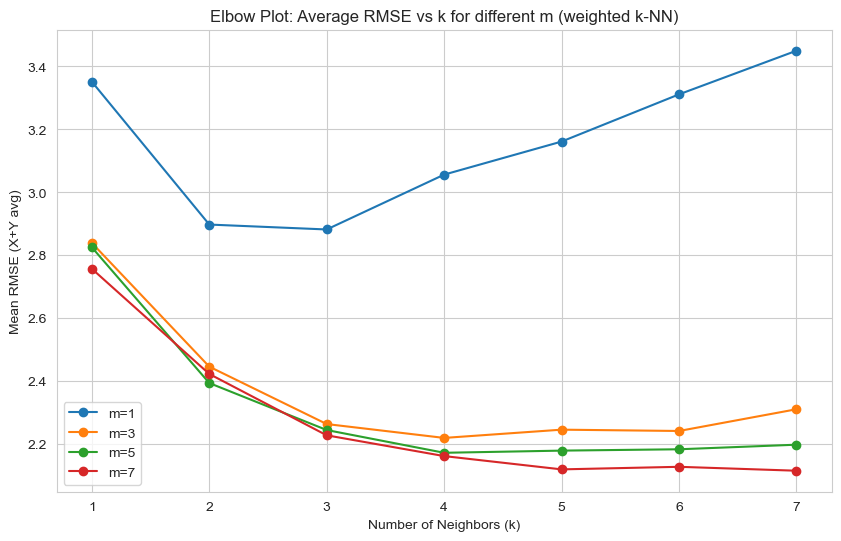

In [271]:
# Perform cross-validation across multiple values of m (angle tolerance) and k (number of neighbors)
cv_results = cross_validate_k_m(
    offline_df=offline_reshaped_filled,
    m_values=[1, 3, 5, 7],
    k_values=list(range(1, 8)),
    v=5,
    weighted=True
)

# Compute average RMSE over both x and y axes for easier plotting
cv_results['rmse_avg'] = (cv_results['rmse_x'] + cv_results['rmse_y']) / 2

plt.figure(figsize=(10, 6))
# Plot one curve per m value
for m_val in sorted(cv_results['m'].unique()):
    subset = cv_results[cv_results['m'] == m_val]
    plt.plot(subset['k'], subset['rmse_avg'], marker='o', label=f"m={m_val}")
# Annotate the plot
plt.title("Elbow Plot: Average RMSE vs k for different m (weighted k-NN)")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean RMSE (X+Y avg)")
plt.legend()
plt.grid(True)
plt.xticks(list(range(1, 8)))
plt.show()

### Visualizing RMSE trends with Elbow plot

To better understand how the number of neighbors (k) and the angular tolerance (m) affect localization accuracy, we plotted the average RMSE values for all tested (m, k) combinations based on cross-validation results.

The elbow plot below highlights several key findings:
* Across all tested values of m, we observe the characteristic elbow shape: RMSE drops sharply as k increases from 1, but tends to plateau or even rise beyond a certain point, indicating diminishing returns or the inclusion of less relevant neighbors.
* The most effective k values generally lie between 3 and 7, which supports earlier manual tuning efforts while providing quantitative evidence for those choices.
* Larger m values (e.g., m = 5 or m = 7) consistently yield lower RMSE, suggesting that allowing more angular flexibility when selecting reference samples improves model robustness against orientation variation.
* Notably, the combination (m = 7, k = 7) yields the lowest average RMSE, with values of approximately rmse_x ≈ 2.56 and rmse_y ≈ 1.67. This makes it the best-performing setting under the current configuration and a strong candidate for deployment.

While this configuration does not yet outperform our manually optimized result (RMSE ≈ 1.72 / 1.22), it offers an automated, reproducible basis for parameter tuning. This is critical for scaling the method across new environments or devices.

### Final Evaluation on Filtered MAC Subset (m = 7, k = 7)
Following our parameter tuning, we applied the best configuration (m = 7, k = 7) to a focused subset of the data filtered by a specific MAC address. This step simulates a realistic deployment where localization relies on signals from a single device.

The model achieved:
* RMSE (X): 1.71
* RMSE (Y): 1.30

These results confirm that the tuned parameters generalize well even under more constrained conditions, and demonstrate the effectiveness of orientation filtering combined with distance-weighted k-NN in a practical setting.

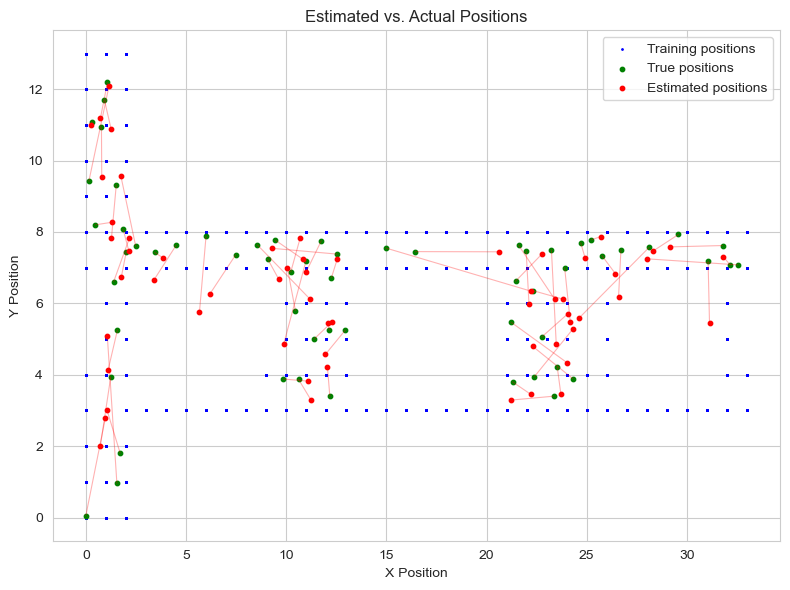

RMSE for X-Coordinate: 1.71
RMSE for Y-Coordinate: 1.30


(np.float64(1.7124779724715216), np.float64(1.2950173404863734))

In [272]:
# Filter data to only include rows where the specific MAC is present
pred_mac = '00:0f:a3:39:e1:c0'

offline_mac = offline_reshaped_filled[offline_reshaped_filled[mac].notna()]
online_mac = online_reshaped[online_reshaped[mac].notna()]

pred_mac = pred_xy_weighted(online_mac, offline_mac, num_angles=7, k=7)
plot_estimates(train=offline_mac, test=online_mac, est_var=pred_mac)
compute_rmse(pred_mac, online_mac)

## Project conclusion

Throughout this project, we successfully developed an orientation-aware k-NN-based indoor localization system and systematically explored how parameter choices affect its performance. By evaluating combinations of angle tolerance (m) and number of neighbors (k) through cross-validation, we identified (m = 7, k = 7) as the configuration with the lowest average RMSE.

While these automatically selected parameters did not outperform our manually tuned best result, they provide a stable, reproducible basis for model selection. This is especially important for adapting the method to new environments, users, or devices where manual tuning would be impractical.

For future work, several directions offer potential improvements:
* incorporating additional signal features (e.g., signal stability or noise),
* optimizing the distance-weighting scheme,
* or transitioning to more advanced machine learning models such as regression or decision trees.

This foundation enables scalable localization without relying on manual heuristics, a key step toward more autonomous and adaptable positioning systems.

### Reference to Related Literature

During the development of this project, we also reviewed relevant scientific literature to better understand common challenges and methodologies in WiFi-based indoor positioning.

Notably, the review paper by Zhuang et al. (2023) provided useful insights into orientation-aware signal processing and k-NN-based localization - elements that align closely with the goals of this project.

> Zhuang, Y., Syed, Z., De Domenico, A., Wang, L., & El-Sheimy, N. (2023). *WiFi-Based Indoor Positioning: Challenges and Solutions*. Applied Sciences, 15(3), 1544. https://doi.org/10.3390/app15031544
